In [14]:
import os, json, math
import numpy as np
import pandas as pd
import networkx as nx
from pathlib import Path

In [15]:
# ------------------------------------------------------------
# Pathway mining + adjacency + weights for 80 DE genes (LCD)
# Requirements:
#   pip install gprofiler-official pandas numpy networkx scikit-learn
# Inputs:
#   /mnt/data/80_DESeq2_significant_genes_lfc_fdr.csv
#     expected columns (case-insensitive): gene | log2fc | padj
# Outputs (in ./results/):
#   gprofiler_enrichment.csv
#   pathways_dict.json
#   gene_pathway_incidence.csv  (genes x pathways, 0/1)
#   gene_adjacency_jaccard.csv  (genes x genes, float)
#   gene_weights.csv            (gene, de_weight, centrality, final_weight)
# ------------------------------------------------------------
import os, json, math
import numpy as np
import pandas as pd
import networkx as nx
from pathlib import Path

# ---- Config
IN_DE = Path("../results/80_DESeq2_significant_genes_lfc_fdr.csv")
OUTDIR = Path("../results/pathway"); OUTDIR.mkdir(exist_ok=True, parents=True)
ORGANISM = "hsapiens"
SOURCES = ["KEGG","REAC","GO:BP","WP"]   # KEGG, Reactome, GO:BP, WikiPathways
ALPHA, BETA = 1.0, 1.0                   # weights for DE vs centrality (agent can tune)
P_ADJ_MAX = 0.10                         # keep enriched terms with adj p <= 0.1 (looser for coverage)

# ---- Helpers
def _std_col(df, names):
    for c in df.columns:
        if c.lower() in names: return c
    raise ValueError(f"Could not find any of {names} in columns: {list(df.columns)}")

def rank_norm(s: pd.Series) -> pd.Series:
    r = s.rank(method="average")
    return (r - r.min()) / (r.max() - r.min() + 1e-12)

# ---- 1) Load DE genes (80)
de_raw = pd.read_csv(IN_DE)
gene_col = _std_col(de_raw, {"gene","genes","symbol","gene_symbol"})
lfc_col  = _std_col(de_raw, {"log2fc","log2_fold_change","log2foldchange","logfc"})
padj_col = _std_col(de_raw, {"padj","fdr","adj_p","adj_pval","padj_bh"})

de = de_raw.rename(columns={gene_col:"gene", lfc_col:"log2FC", padj_col:"padj"})
de["gene"] = de["gene"].astype(str)
gene_list = de["gene"].dropna().unique().tolist()
if len(gene_list) == 0:
    raise ValueError("No genes found in input!")

# ---- 2) g:Profiler enrichment
# NOTE: This calls the public g:Profiler API; requires internet.
from gprofiler import GProfiler
gp = GProfiler(return_dataframe=True)
enr = gp.profile(
    organism=ORGANISM,
    query=gene_list,
    sources=SOURCES,
    user_threshold=P_ADJ_MAX,
    no_evidences=False
)
# Keep only terms with intersections (genes)
enr = enr[enr["intersections"].notna()].copy()
enr.to_csv(OUTDIR / "gprofiler_enrichment.csv", index=False)

# ---- 3) Build pathway dictionary and incidence matrix
# g:Profiler 'intersections' are the overlapping genes from your list (comma-sep)
def parse_genes(x):
    if isinstance(x, str):
        return set([g.strip() for g in x.split(",") if g.strip()])
    return set()

# --- robust column picking for IDs/names across g:Profiler versions ---
cols = {c.lower(): c for c in enr.columns}  # case-insensitive

# possible id columns in different lib versions
id_candidates = ["term_id", "native", "id", "term", "term_code"]
name_candidates = ["name", "term_name", "description", "term_description", "term_name_with_source"]

id_col = next((cols[c] for c in id_candidates if c in cols), None)
name_col = next((cols[c] for c in name_candidates if c in cols), None)

# parse intersections (can be comma-separated string OR list)
def to_set(x):
    if isinstance(x, str):
        return set(g.strip() for g in x.split(",") if g.strip())
    if isinstance(x, (list, tuple, set)):
        return set(map(str, x))
    return set()

int_col = cols.get("intersections", None)
if int_col is None:
    # some older versions store per-query columns like 'query_0', etc.; fallback
    q_cols = [c for c in enr.columns if c.lower().startswith("query_")]
    if q_cols:
        enr["genes_in_term"] = enr[q_cols].apply(
            lambda row: set().union(*(to_set(row[c]) for c in q_cols)), axis=1
        )
    else:
        raise ValueError("No 'intersections' (or query_*) columns found in g:Profiler result.")
else:
    enr["genes_in_term"] = enr[int_col].apply(to_set)

# build pathway_id and pathway_name safely
if id_col is not None:
    enr["pathway_id"] = enr["source"].astype(str) + ":" + enr[id_col].astype(str)
else:
    # fallback: synthesize a stable id from source+name or row index
    if name_col is not None:
        enr["pathway_id"] = enr["source"].astype(str) + ":" + enr[name_col].astype(str)
    else:
        enr["pathway_id"] = enr["source"].astype(str) + ":row" + enr.index.astype(str)

if name_col is not None:
    enr["pathway_name"] = enr[name_col].astype(str)
else:
    enr["pathway_name"] = enr["pathway_id"]

# keep only terms with ≥2 genes from your list
enr = enr[enr["genes_in_term"].apply(lambda s: isinstance(s, set) and len(s) >= 2)]


# pathway -> set(genes)
pathways = {row["pathway_id"]+"|"+row["pathway_name"]: row["genes_in_term"]
            for _, row in enr.iterrows()
            if len(row["genes_in_term"]) >= 2}   # keep terms with >=2 genes

# save pathways dict
with open(OUTDIR / "pathways_dict.json","w") as f:
    json.dump({k: sorted(list(v)) for k,v in pathways.items()}, f, indent=2)

# Construct gene x pathway incidence for your genes only
genes = sorted(set(gene_list))
pw_names = list(pathways.keys())
inc = pd.DataFrame(0, index=genes, columns=pw_names, dtype=int)
for p, gset in pathways.items():
    present = sorted(gset & set(genes))
    if present:
        inc.loc[present, p] = 1
inc.to_csv(OUTDIR / "gene_pathway_incidence.csv")

# ---- 4) Build gene–gene adjacency by shared pathways (Jaccard of memberships)
def jaccard(a: np.ndarray, b: np.ndarray) -> float:
    inter = int((a & b).sum())
    union = int((a | b).sum())
    return inter / union if union > 0 else 0.0

inc_bool = inc.astype(bool).to_numpy()
gidx = inc.index.tolist()
A = np.zeros((len(gidx), len(gidx)), dtype=float)
for i in range(len(gidx)):
    Ai = inc_bool[i]
    for j in range(i+1, len(gidx)):
        Aj = inc_bool[j]
        Aij = jaccard(Ai, Aj)
        if Aij>0:
            A[i,j] = Aij; A[j,i] = Aij

adj = pd.DataFrame(A, index=gidx, columns=gidx)
adj.to_csv(OUTDIR / "gene_adjacency_jaccard.csv")

# ---- 5) Centrality (degree = sum of weights), DE weight, and final weight
deg = pd.Series(A.sum(axis=1), index=gidx, name="centrality")

# DE weight = |LFC| * -log10(padj), clipped for safety
de2 = de.set_index("gene").reindex(gidx)
de_strength = (de2["log2FC"].abs() * (-np.log10(np.clip(de2["padj"], 1e-300, 1)))).fillna(0.0)
de_strength.name = "de_weight"

w = ALPHA*rank_norm(de_strength) + BETA*rank_norm(deg)
# rescale to (0,1] to avoid zeros
w = (w - w.min())/(w.max() - w.min() + 1e-12) + 1e-6
weights = pd.concat([de_strength, deg, w.rename("final_weight")], axis=1)
weights.to_csv(OUTDIR / "gene_weights.csv")

print("Done:")
print(f"  {len(genes)} genes")
print(f"  {inc.shape[1]} enriched pathways kept (padj <= {P_ADJ_MAX})")
print("Saved:")
print(f"  {OUTDIR/'gprofiler_enrichment.csv'}")
print(f"  {OUTDIR/'pathways_dict.json'}")
print(f"  {OUTDIR/'gene_pathway_incidence.csv'}")
print(f"  {OUTDIR/'gene_adjacency_jaccard.csv'}")
print(f"  {OUTDIR/'gene_weights.csv'}")

# -------- Optional: weighted PCA if you already have VST expression --------
# If you have an expression matrix `expr_vst` (samples x genes, columns = gidx),
# you can uncomment this block to produce weighted PCs immediately.
"""
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# expr_vst = pd.read_csv("/path/to/your_vst_matrix.csv", index_col=0)
expr_vst = expr_vst.reindex(columns=gidx)   # align columns
X = expr_vst.values
Xz = StandardScaler(with_mean=True, with_std=True).fit_transform(X)

sqrtw = np.sqrt(weights.loc[gidx, "final_weight"].values)
Xw = Xz * sqrtw[None, :]

pca = PCA(n_components=100, svd_solver="full", random_state=0)
Z = pca.fit_transform(Xw)
pd.DataFrame(Z, index=expr_vst.index).to_csv(OUTDIR / "weighted_pca_scores.csv")
pd.DataFrame(pca.components_, columns=gidx).to_csv(OUTDIR / "weighted_pca_loadings.csv")
"""


Done:
  80 genes
  15 enriched pathways kept (padj <= 0.1)
Saved:
  ../results/pathway/gprofiler_enrichment.csv
  ../results/pathway/pathways_dict.json
  ../results/pathway/gene_pathway_incidence.csv
  ../results/pathway/gene_adjacency_jaccard.csv
  ../results/pathway/gene_weights.csv


'\nfrom sklearn.decomposition import PCA\nfrom sklearn.preprocessing import StandardScaler\n\n# expr_vst = pd.read_csv("/path/to/your_vst_matrix.csv", index_col=0)\nexpr_vst = expr_vst.reindex(columns=gidx)   # align columns\nX = expr_vst.values\nXz = StandardScaler(with_mean=True, with_std=True).fit_transform(X)\n\nsqrtw = np.sqrt(weights.loc[gidx, "final_weight"].values)\nXw = Xz * sqrtw[None, :]\n\npca = PCA(n_components=100, svd_solver="full", random_state=0)\nZ = pca.fit_transform(Xw)\npd.DataFrame(Z, index=expr_vst.index).to_csv(OUTDIR / "weighted_pca_scores.csv")\npd.DataFrame(pca.components_, columns=gidx).to_csv(OUTDIR / "weighted_pca_loadings.csv")\n'

In [16]:
weights

,de_weight,centrality,final_weight
AADACL3,22.019044,0.000000,0.350319
ALDOC,75.843763,1.898291,0.871143
AMER2,1.723972,0.000000,0.012740
ANGPTL8,39.262223,0.000000,0.420383
AQP4,4.185989,0.000000,0.089173
...,...,...,...
TRPM8,2.584746,0.000000,0.038218
TTYH1,13.323461,0.000000,0.242039
UGT1A7,2.870966,1.898291,0.444391
UNC13C,25.365625,0.000000,0.369428


In [17]:
df_gene_annot = pd.read_csv('../data/Human.GRCh38.p13.annot.tsv', sep='\t', index_col = None, header=0, low_memory=False)
df_gene_annot

,GeneID,Symbol,Description,Synonyms,GeneType,EnsemblGeneID,Status,ChrAcc,ChrStart,ChrStop,Orientation,Length,GOFunctionID,GOProcessID,GOComponentID,GOFunction,GOProcess,GOComponent
0,100287102,DDX11L1,DEAD/H-box helicase 11 like 1 (pseudogene),NaN,pseudo,ENSG00000290825,active,NC_000001.11,11874,14409,positive,1652,NaN,NaN,NaN,NaN,NaN,NaN
1,653635,WASH7P,"WASP family homolog 7, pseudogene",FAM39F|WASH5P,pseudo,NaN,active,NC_000001.11,14362,29370,negative,1769,NaN,NaN,NaN,NaN,NaN,NaN
2,102466751,MIR6859-1,microRNA 6859-1,hsa-mir-6859-1,ncRNA,ENSG00000278267,active,NC_000001.11,17369,17436,negative,68,NaN,NaN,NaN,NaN,NaN,NaN
3,107985730,MIR1302-2HG,MIR1302-2 host gene,NaN,ncRNA,NaN,active,NC_000001.11,29926,31295,positive,538,NaN,NaN,NaN,NaN,NaN,NaN
4,100302278,MIR1302-2,microRNA 1302-2,MIRN1302-2|hsa-mir-1302-2,ncRNA,ENSG00000284332,active,NC_000001.11,30366,30503,positive,138,NaN,GO:0035195,NaN,NaN,miRNA-mediated gene silencing,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39371,4541,ND6,NADH dehydrogenase subunit 6,MTND6,protein-coding,NaN,active,NC_012920.1,14149,14673,negative,525,GO:0008137,GO:0006120///GO:0009060///GO:0032981///GO:0035...,GO:0005739///GO:0005743///GO:0005747,NADH dehydrogenase (ubiquinone) activity,"mitochondrial electron transport, NADH to ubiq...",mitochondrion///mitochondrial inner membrane//...
39372,4556,TRNE,tRNA-Glu,MTTE,tRNA,NaN,active,NC_012920.1,14674,14742,negative,69,NaN,NaN,NaN,NaN,NaN,NaN
39373,4519,CYTB,cytochrome b,MTCYB,protein-coding,NaN,active,NC_012920.1,14747,15887,positive,1141,GO:0008121///GO:0046872,GO:0006122///GO:0045333///GO:1902600,GO:0005739///GO:0005743///GO:0005750///GO:0016020,ubiquinol-cytochrome-c reductase activity///me...,"mitochondrial electron transport, ubiquinol to...",mitochondrion///mitochondrial inner membrane//...
39374,4576,TRNT,tRNA-Thr,MTTT,tRNA,NaN,active,NC_012920.1,15888,15953,positive,66,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# Filter expression matrix to pathway genes and convert index to symbols
gene_mapping = df_gene_annot[df_gene_annot['Symbol'].isin(weights.index)]
id_to_symbol = dict(zip(gene_mapping['GeneID'].astype(str), gene_mapping['Symbol']))
expr_vst = pd.read_csv("../results/GSE95640_DeSEQ2_normalized_counts.csv", index_col=0)
expr_vst = expr_vst[expr_vst.index.astype(str).isin(id_to_symbol.keys())]
expr_vst.index = expr_vst.index.astype(str).map(id_to_symbol)
expr_vst.index.name = None
print(f"Filtered to {expr_vst.shape[0]} pathway genes")
expr_vst

Filtered to 80 pathway genes


,GSM2520157,GSM2520158,GSM2520159,GSM2520160,GSM2520161,GSM2520162,GSM2520163,GSM2520164,GSM2520165,GSM2520166,...,GSM2520529,GSM2520530,GSM2520531,GSM2520532,GSM2520533,GSM2520534,GSM2520535,GSM2520536,GSM2520537,GSM2520538
AADACL3,4.201004,69.851929,5.239848,39.328181,8.208981,16.377468,1.069782,14.903009,98.121454,48.792065,...,26.026893,2.864412,15.036634,30.714882,3.816900,4.194643,8.629877,3.783670,32.829682,4.514742
COL11A1,47.611384,485.583574,21.832698,691.818452,332.090612,93.897484,21.395642,189.764982,72.890223,417.532098,...,96.099298,166.852007,88.852839,158.181643,1.908450,45.302142,85.435784,20.810187,291.185003,115.125911
CHIT1,1534.766968,555.435503,263.738991,2243.493947,3585.086069,115.734109,1528.718589,55.637901,231.286285,237.561366,...,223.230662,270.686947,4152.161494,162.788875,30.535201,373.323206,463.424407,367.016017,44.248701,1708.829698
LOC105374435,12.603013,16.899660,2.619924,35.752892,13.432879,5.459156,4.279128,10.928873,22.427761,22.396358,...,6.006206,7.161030,6.151350,15.357441,5.725350,0.838929,5.177926,4.729588,14.273775,0.752457
GKN1,0.000000,6.759864,0.000000,5.362934,1.492542,1.091831,1.069782,4.967670,3.504338,4.799220,...,2.002069,0.716103,0.683483,8.446593,2.862675,2.516786,1.725975,0.945918,1.427377,2.257371
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P2RX6P,12.603013,61.965421,9.606387,44.691114,12.686608,20.744793,9.628039,30.799552,54.667667,43.192976,...,29.029996,27.211915,30.073268,74.483589,8.588025,6.711428,29.341583,9.459176,32.829682,9.029483
MXRA5,1524.964625,3723.558494,771.130892,5967.157606,4056.729365,7892.847847,1427.089292,3939.362070,6375.791919,6131.002938,...,1201.241231,1648.469186,1597.300644,3654.303100,484.746313,787.753910,1889.943111,941.187983,3685.488616,1530.497404
LINC02154,14.003348,1.126644,6.986463,35.752892,11.194066,0.000000,51.349540,0.000000,2.803470,3.999350,...,22.022756,2.864412,25.972368,6.910848,0.954225,0.838929,6.040914,4.729588,0.000000,5.267199
LOC105373202,23.805692,98.018030,15.719543,202.003837,33.582197,120.101434,20.325859,177.842575,142.976976,267.956423,...,50.051718,55.856037,82.701488,129.770377,11.450700,35.234999,43.149386,28.377527,127.036594,9.781940


Loaded sample annotation: (382, 3)
Found 382 matching samples
Colored by binary group: ['Baseline', 'After LCD']


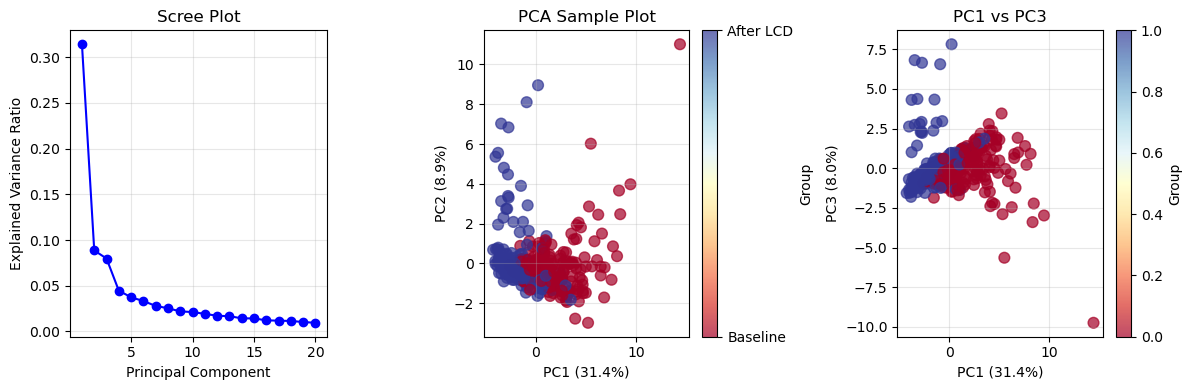

Weighted PCA done with 80 genes, 20 components


In [19]:
# Weighted PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Align expression matrix with weights (both indexed by gene symbols)
common_genes = list(set(expr_vst.index) & set(weights.index))
expr_aligned = expr_vst.loc[common_genes]
weights_aligned = weights.loc[common_genes, "final_weight"]

# Standardize and weight
X = expr_aligned.T.values  # transpose: samples x genes
Xz = StandardScaler().fit_transform(X)
sqrtw = np.sqrt(weights_aligned.values)
Xw = Xz * sqrtw[None, :]

# PCA
n_components = min(len(common_genes)-1, X.shape[0]-1, 20)  # max 20 PCs or limited by data
pca = PCA(n_components=n_components, random_state=0)
Z = pca.fit_transform(Xw)

# Save PCA scores
pca_df = pd.DataFrame(Z, index=expr_aligned.columns)
pca_df.to_csv(OUTDIR / "weighted_pca_scores.csv")

# Load and align sample annotation
try:
    sample_annot = pd.read_csv("../results/GSE95640_sample_annotation.csv", index_col=0)
    print(f"Loaded sample annotation: {sample_annot.shape}")
    
    # Match using sample_name column
    pca_samples = set(pca_df.index)
    annot_sample_names = set(sample_annot['sample_name'])
    common_samples = list(pca_samples & annot_sample_names)
    
    if len(common_samples) > 0:
        print(f"Found {len(common_samples)} matching samples")
        # Create mapping from sample_name to annotation
        sample_name_to_annot = sample_annot.set_index('sample_name')
        sample_annot_aligned = sample_name_to_annot.loc[common_samples]
        pca_df_aligned = pca_df.loc[common_samples]
        Z_aligned = pca_df_aligned.values
        use_annotation = True
    else:
        print("No matching samples found")
        use_annotation = False
        
except Exception as e:
    print(f"Error loading sample annotation: {e}")
    use_annotation = False

# 1. Scree plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid(True, alpha=0.3)

# 2. Scatter plot PC1 vs PC2 with group coloring
plt.subplot(1, 3, 2)
if use_annotation and 'group_0_1' in sample_annot_aligned.columns:
    # Color by binary group (0/1)
    colors = sample_annot_aligned['group_0_1'].values
    unique_groups = sample_annot_aligned['group_0_1'].unique()
    group_labels = ['Baseline', 'After LCD']
    
    scatter = plt.scatter(Z_aligned[:, 0], Z_aligned[:, 1], 
                         c=colors, cmap='RdYlBu', alpha=0.7, s=60)
    cbar = plt.colorbar(scatter, label='Group')
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(group_labels)
    print(f"Colored by binary group: {group_labels}")
    
elif use_annotation and 'group' in sample_annot_aligned.columns:
    # Fallback to descriptive group column
    colors = sample_annot_aligned['group'].astype('category').cat.codes
    scatter = plt.scatter(Z_aligned[:, 0], Z_aligned[:, 1], 
                         c=colors, cmap='Set1', alpha=0.7, s=60)
    plt.colorbar(scatter, label='Group')
    print("Colored by descriptive group")
else:
    plt.scatter(Z[:, 0], Z[:, 1], alpha=0.7, s=60, color='steelblue')
    print("No group coloring available")

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA Sample Plot')
plt.grid(True, alpha=0.3)

# 3. PC1 vs PC3 
plt.subplot(1, 3, 3)
if use_annotation and 'group_0_1' in sample_annot_aligned.columns:
    colors = sample_annot_aligned['group_0_1'].values
    scatter = plt.scatter(Z_aligned[:, 0], Z_aligned[:, 2], 
                         c=colors, cmap='RdYlBu', alpha=0.7, s=60)
    plt.colorbar(scatter, label='Group')
else:
    plt.scatter(Z[:, 0], Z[:, 2], alpha=0.7, s=60, color='steelblue')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
plt.title('PC1 vs PC3')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTDIR / "weighted_pca_plots.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Weighted PCA done with {len(common_genes)} genes, {n_components} components")

In [20]:
sample_annot = pd.read_csv("../results/GSE95640_sample_annotation.csv", index_col=0)
sample_annot

,sample_name,group,group_0_1
B00EVBV,GSM2520157,time: CID1 is for the baseline without LCD,0
B00EVBY,GSM2520158,time: CID1 is for the baseline without LCD,0
B00EVC0,GSM2520159,time: CID1 is for the baseline without LCD,0
B00EVC2,GSM2520160,time: CID1 is for the baseline without LCD,0
B00EVC4,GSM2520161,time: CID1 is for the baseline without LCD,0
...,...,...,...
B00EWA9,GSM2520534,time: CID2 is after 8 weeks of LCD,1
B00EWAE,GSM2520535,time: CID2 is after 8 weeks of LCD,1
B00EWAF,GSM2520536,time: CID2 is after 8 weeks of LCD,1
B00EWEV,GSM2520537,time: CID1 is for the baseline without LCD,0


=== Weighted PCA Classification Analysis ===
Available annotation columns: ['group', 'group_0_1']
Using column: group_0_1
Classes: ['Baseline', 'After LCD']
Class distribution: 0    191
1    191
Name: count, dtype: int64
Data shape: X_pca=(382, 20), y=382

--- Random Forest ---
Test Accuracy: 0.878
Test Accuracy: 0.878
CV Accuracy: 0.861 ± 0.040

Classification Report:
              precision    recall  f1-score   support

    Baseline       0.83      0.95      0.89        58
   After LCD       0.94      0.81      0.87        57

    accuracy                           0.88       115
   macro avg       0.89      0.88      0.88       115
weighted avg       0.89      0.88      0.88       115


--- Logistic Regression ---
Test Accuracy: 0.878
CV Accuracy: 0.880 ± 0.024

Classification Report:
              precision    recall  f1-score   support

    Baseline       0.84      0.93      0.89        58
   After LCD       0.92      0.82      0.87        57

    accuracy                        

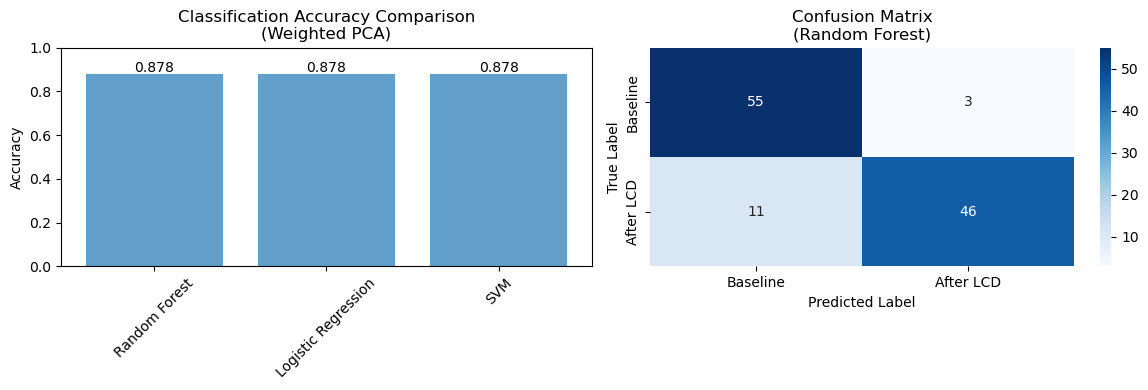

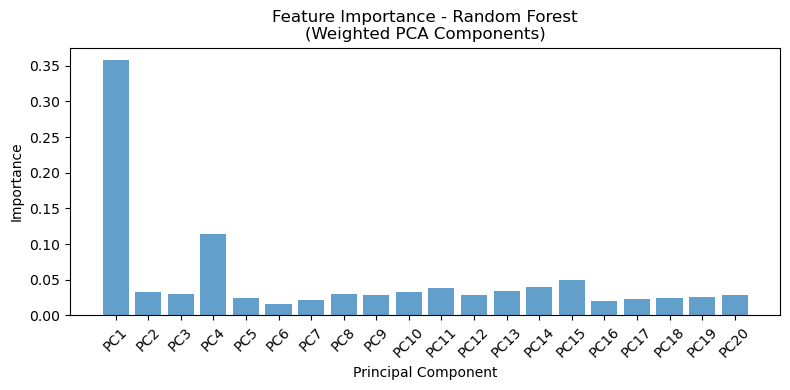


Best classifier: Random Forest (Accuracy: 0.878)
Classification analysis saved to results/pathway/


In [21]:
# -------- Classification Analysis using Weighted PCA Results --------
# Similar to sig_pca_classification.ipynb but using pathway-weighted PCA

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

if 'sample_annot_aligned' in locals() and sample_annot_aligned is not None:
    print("=== Weighted PCA Classification Analysis ===")
    print(f"Available annotation columns: {list(sample_annot_aligned.columns)}")
    
    # Use group_0_1 for binary classification (0: baseline, 1: after LCD)
    if 'group_0_1' in sample_annot_aligned.columns:
        group_col = 'group_0_1'
        class_labels = ['Baseline', 'After LCD']
    elif 'group' in sample_annot_aligned.columns:
        group_col = 'group'
        class_labels = None  # Will be derived from data
    else:
        print("No suitable group column found")
        group_col = None
    
    if group_col is not None:
        # Prepare data for classification
        X_pca = Z_aligned  # Weighted PCA scores (aligned)
        y = sample_annot_aligned[group_col].values
        
        # Encode labels
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        
        # Use custom labels if available
        if class_labels is not None and len(le.classes_) == 2:
            display_classes = class_labels
        else:
            display_classes = le.classes_
        
        print(f"Using column: {group_col}")
        print(f"Classes: {display_classes}")
        print(f"Class distribution: {pd.Series(y).value_counts()}")
        print(f"Data shape: X_pca={X_pca.shape}, y={len(y)}")
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X_pca, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
        )
        
        # Initialize classifiers
        classifiers = {
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
            'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
            'SVM': SVC(random_state=42, probability=True)
        }
        
        # Train and evaluate classifiers
        results = {}
        
        for name, clf in classifiers.items():
            print(f"\n--- {name} ---")
            
            # Train
            clf.fit(X_train, y_train)
            
            # Predict
            y_pred = clf.predict(X_test)
            
            # Accuracy
            accuracy = accuracy_score(y_test, y_pred)
            results[name] = accuracy
            print(f"Test Accuracy: {accuracy:.3f}")
            
            # Cross-validation
            cv_scores = cross_val_score(clf, X_pca, y_encoded, cv=StratifiedKFold(5), scoring='accuracy')
            print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
            
            # Classification report
            print("\nClassification Report:")
            print(classification_report(y_test, y_pred, target_names=display_classes))
        
        # Plot results
        plt.figure(figsize=(12, 4))
        
        # Accuracy comparison
        plt.subplot(1, 2, 1)
        methods = list(results.keys())
        accuracies = list(results.values())
        plt.bar(methods, accuracies, alpha=0.7)
        plt.title('Classification Accuracy Comparison\n(Weighted PCA)')
        plt.ylabel('Accuracy')
        plt.xticks(rotation=45)
        plt.ylim(0, 1)
        for i, v in enumerate(accuracies):
            plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
        
        # Confusion matrix for best classifier
        best_clf_name = max(results, key=results.get)
        best_clf = classifiers[best_clf_name]
        best_clf.fit(X_train, y_train)
        y_pred_best = best_clf.predict(X_test)
        
        plt.subplot(1, 2, 2)
        cm = confusion_matrix(y_test, y_pred_best)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=display_classes, yticklabels=display_classes)
        plt.title(f'Confusion Matrix\n({best_clf_name})')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        
        plt.tight_layout()
        plt.savefig(OUTDIR / "weighted_pca_classification.png", dpi=300, bbox_inches='tight')
        plt.show()
        
        # Feature importance for Random Forest
        if 'Random Forest' in classifiers:
            rf = classifiers['Random Forest']
            rf.fit(X_pca, y_encoded)
            
            plt.figure(figsize=(8, 4))
            importances = rf.feature_importances_
            pc_names = [f'PC{i+1}' for i in range(len(importances))]
            
            plt.bar(pc_names, importances, alpha=0.7)
            plt.title('Feature Importance - Random Forest\n(Weighted PCA Components)')
            plt.xlabel('Principal Component')
            plt.ylabel('Importance')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.savefig(OUTDIR / "weighted_pca_feature_importance.png", dpi=300, bbox_inches='tight')
            plt.show()
        
        print(f"\nBest classifier: {best_clf_name} (Accuracy: {results[best_clf_name]:.3f})")
        print("Classification analysis saved to results/pathway/")
    
else:
    print("No aligned sample annotation found - skipping classification analysis")

In [22]:
# Reload sample annotation and debug matching
sample_annot = pd.read_csv("../results/GSE95640_sample_annotation.csv", index_col=0)

print("PCA sample names (first 10):")
print(list(pca_df.index[:10]))
print(f"Total PCA samples: {len(pca_df.index)}")

print("\nAnnotation sample names (first 10):")
print(list(sample_annot.index[:10]))
print(f"Total annotation samples: {len(sample_annot.index)}")

print("\nAnnotation sample_name column (first 10):")
print(list(sample_annot['sample_name'][:10]))

# Check if sample_name column matches PCA index
pca_samples = set(pca_df.index)
annot_samples = set(sample_annot.index)
annot_sample_names = set(sample_annot['sample_name'])

print(f"\nOverlap PCA vs annotation index: {len(pca_samples & annot_samples)}")
print(f"Overlap PCA vs annotation sample_name: {len(pca_samples & annot_sample_names)}")

if len(pca_samples & annot_sample_names) > 0:
    print("✓ Found match using sample_name column")
    # Create mapping from sample_name to annotation row
    sample_name_to_annot = sample_annot.set_index('sample_name')
    common_samples = list(pca_samples & annot_sample_names)
    print(f"Found {len(common_samples)} matching samples")
    
    # Align data
    sample_annot_aligned = sample_name_to_annot.loc[common_samples]
    pca_df_aligned = pca_df.loc[common_samples]
    Z_aligned = pca_df_aligned.values
    
    print("Sample alignment successful!")
    print(f"Z_aligned shape: {Z_aligned.shape}")
    print(f"Sample annotation shape: {sample_annot_aligned.shape}")

PCA sample names (first 10):
['GSM2520157', 'GSM2520158', 'GSM2520159', 'GSM2520160', 'GSM2520161', 'GSM2520162', 'GSM2520163', 'GSM2520164', 'GSM2520165', 'GSM2520166']
Total PCA samples: 382

Annotation sample names (first 10):
['B00EVBV', 'B00EVBY', 'B00EVC0', 'B00EVC2', 'B00EVC4', 'B00EVC7', 'B00EVC9', 'B00EVCA', 'B00EVCE', 'B00EVCF']
Total annotation samples: 382

Annotation sample_name column (first 10):
['GSM2520157', 'GSM2520158', 'GSM2520159', 'GSM2520160', 'GSM2520161', 'GSM2520162', 'GSM2520163', 'GSM2520164', 'GSM2520165', 'GSM2520166']

Overlap PCA vs annotation index: 0
Overlap PCA vs annotation sample_name: 382
✓ Found match using sample_name column
Found 382 matching samples
Sample alignment successful!
Z_aligned shape: (382, 20)
Sample annotation shape: (382, 2)


=== ROC Curve Analysis with Confidence Bands ===
Computing ROC curves for Random Forest...
  Completed fold 1/5
  Completed fold 1/5
  Random Forest: AUC = 0.926 ± 0.025
Computing ROC curves for Logistic Regression...
  Completed fold 1/5
  Random Forest: AUC = 0.926 ± 0.025
Computing ROC curves for Logistic Regression...
  Completed fold 1/5
  Logistic Regression: AUC = 0.933 ± 0.021
Computing ROC curves for SVM...
  Logistic Regression: AUC = 0.933 ± 0.021
Computing ROC curves for SVM...
  Completed fold 1/5
  Completed fold 1/5
  SVM: AUC = 0.932 ± 0.027
  SVM: AUC = 0.932 ± 0.027


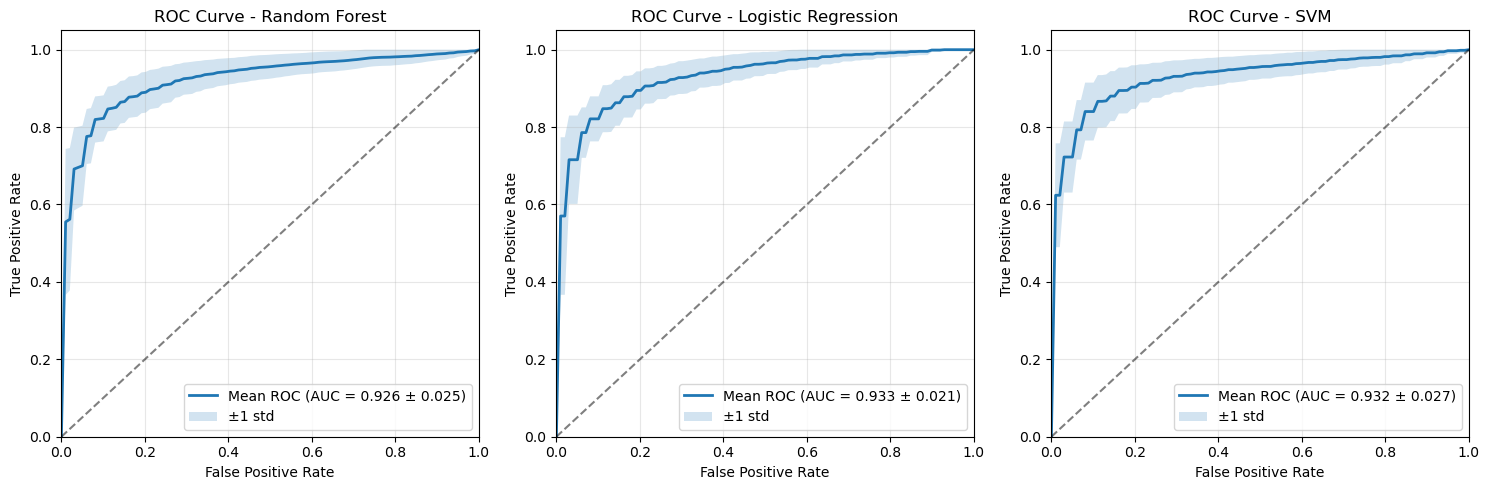

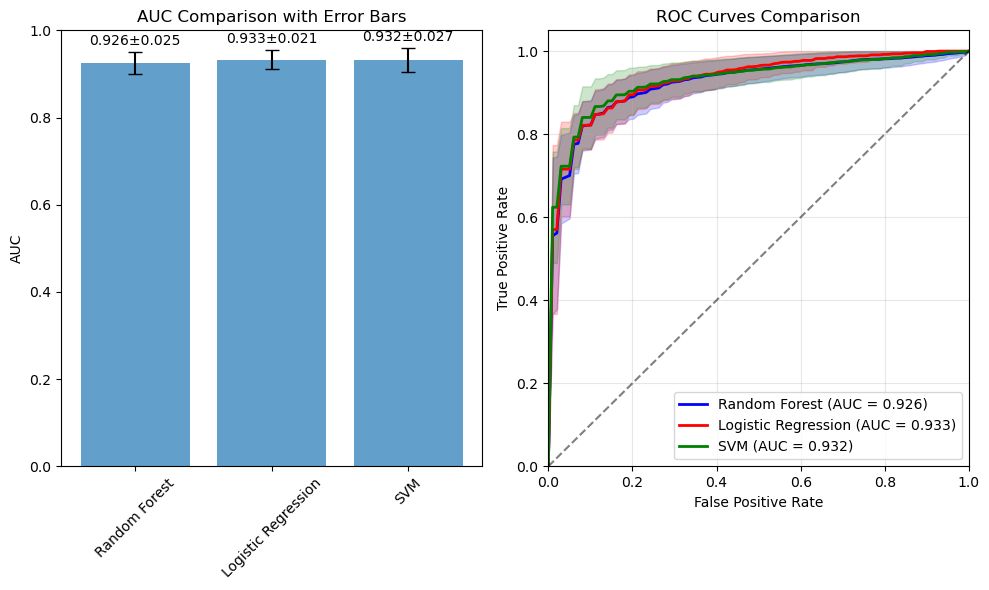


=== Statistical Comparison ===
Best: Logistic Regression (AUC = 0.933)
Worst: Random Forest (AUC = 0.926)
Paired t-test: t = 5.435, p = 0.000
Significant difference: Yes

ROC analysis saved to results/pathway/


In [23]:
# -------- ROC Curve Analysis with Confidence Bands --------
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
import numpy as np

if 'sample_annot_aligned' in locals() and sample_annot_aligned is not None:
    print("=== ROC Curve Analysis with Confidence Bands ===")
    
    # Use the aligned data
    X_pca = Z_aligned
    y = sample_annot_aligned['group_0_1'].values
    
    # Bootstrap parameters (reduced for faster execution)
    n_bootstraps = 200  # Reduced from 1000
    n_folds = 5
    
    # Store ROC curves for each classifier
    roc_data = {}
    
    plt.figure(figsize=(15, 5))
    
    for idx, (name, clf) in enumerate(classifiers.items()):
        print(f"Computing ROC curves for {name}...")
        
        # Store FPR/TPR for bootstrap samples
        tprs = []
        aucs = []
        mean_fpr = np.linspace(0, 1, 100)
        
        # Cross-validation with bootstrap for confidence bands
        cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
        
        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_pca, y)):
            X_train_cv, X_test_cv = X_pca[train_idx], X_pca[test_idx]
            y_train_cv, y_test_cv = y[train_idx], y[test_idx]
            
            # Bootstrap sampling within each fold
            n_boot_per_fold = n_bootstraps // n_folds
            for i in range(n_boot_per_fold):
                # Bootstrap sample from training set
                boot_idx = np.random.choice(len(X_train_cv), size=len(X_train_cv), replace=True)
                X_boot = X_train_cv[boot_idx]
                y_boot = y_train_cv[boot_idx]
                
                # Train classifier
                clf_boot = clf.__class__(**clf.get_params())
                clf_boot.fit(X_boot, y_boot)
                
                # Predict probabilities on test set
                if hasattr(clf_boot, "predict_proba"):
                    y_score = clf_boot.predict_proba(X_test_cv)[:, 1]
                else:
                    y_score = clf_boot.decision_function(X_test_cv)
                
                # Compute ROC curve
                fpr, tpr, _ = roc_curve(y_test_cv, y_score)
                roc_auc = auc(fpr, tpr)
                
                # Interpolate to common FPR values
                interp_tpr = np.interp(mean_fpr, fpr, tpr)
                interp_tpr[0] = 0.0
                tprs.append(interp_tpr)
                aucs.append(roc_auc)
            
            if fold_idx == 0:  # Progress indicator
                print(f"  Completed fold {fold_idx + 1}/{n_folds}")
        
        # Convert to arrays
        tprs = np.array(tprs)
        aucs = np.array(aucs)
        
        # Compute mean and std
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = np.mean(aucs)
        std_auc = np.std(aucs)
        
        std_tpr = np.std(tprs, axis=0)
        tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
        tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
        
        # Store data
        roc_data[name] = {
            'mean_fpr': mean_fpr,
            'mean_tpr': mean_tpr,
            'std_tpr': std_tpr,
            'mean_auc': mean_auc,
            'std_auc': std_auc,
            'aucs': aucs
        }
        
        # Plot ROC curve with confidence bands
        plt.subplot(1, 3, idx + 1)
        
        # Plot mean ROC curve
        plt.plot(mean_fpr, mean_tpr, 
                label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})',
                linewidth=2)
        
        # Plot confidence bands
        plt.fill_between(mean_fpr, tprs_lower, tprs_upper, 
                        alpha=0.2, label='±1 std')
        
        # Plot diagonal reference line
        plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {name}')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        
        print(f"  {name}: AUC = {mean_auc:.3f} ± {std_auc:.3f}")
    
    plt.tight_layout()
    plt.savefig(OUTDIR / "weighted_pca_roc_curves.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Summary comparison plot
    plt.figure(figsize=(10, 6))
    
    # AUC comparison with error bars
    names = list(roc_data.keys())
    mean_aucs = [roc_data[name]['mean_auc'] for name in names]
    std_aucs = [roc_data[name]['std_auc'] for name in names]
    
    plt.subplot(1, 2, 1)
    bars = plt.bar(names, mean_aucs, yerr=std_aucs, capsize=5, alpha=0.7)
    plt.ylabel('AUC')
    plt.title('AUC Comparison with Error Bars')
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    
    # Add value labels on bars
    for bar, auc, std in zip(bars, mean_aucs, std_aucs):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
                f'{auc:.3f}±{std:.3f}', ha='center', va='bottom')
    
    # Combined ROC curves
    plt.subplot(1, 2, 2)
    colors = ['blue', 'red', 'green']
    
    for i, (name, data) in enumerate(roc_data.items()):
        plt.plot(data['mean_fpr'], data['mean_tpr'], 
                color=colors[i], linewidth=2,
                label=f'{name} (AUC = {data["mean_auc"]:.3f})')
        plt.fill_between(data['mean_fpr'], 
                        np.maximum(data['mean_tpr'] - data['std_tpr'], 0),
                        np.minimum(data['mean_tpr'] + data['std_tpr'], 1),
                        color=colors[i], alpha=0.2)
    
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves Comparison')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTDIR / "weighted_pca_roc_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Statistical significance test between best and worst AUC
    best_name = max(roc_data.keys(), key=lambda x: roc_data[x]['mean_auc'])
    worst_name = min(roc_data.keys(), key=lambda x: roc_data[x]['mean_auc'])
    
    from scipy import stats
    best_aucs = roc_data[best_name]['aucs']
    worst_aucs = roc_data[worst_name]['aucs']
    
    # Paired t-test
    t_stat, p_value = stats.ttest_rel(best_aucs, worst_aucs)
    
    print(f"\n=== Statistical Comparison ===")
    print(f"Best: {best_name} (AUC = {roc_data[best_name]['mean_auc']:.3f})")
    print(f"Worst: {worst_name} (AUC = {roc_data[worst_name]['mean_auc']:.3f})")
    print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.3f}")
    print(f"Significant difference: {'Yes' if p_value < 0.05 else 'No'}")
    
    print("\nROC analysis saved to results/pathway/")
    
else:
    print("No aligned sample annotation found - skipping ROC analysis")

=== Weighted PCA with 26 Components ===
Weighted PCA with 26 components completed
Using 80 genes
Data shape: (382, 26)
Total explained variance: 87.6%


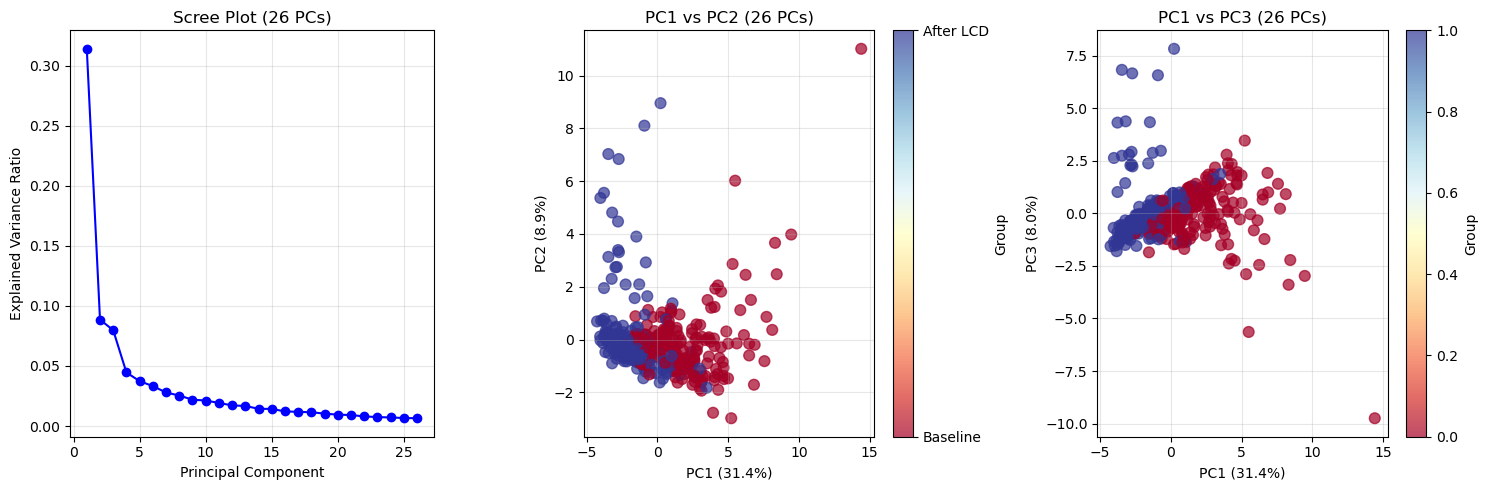

In [24]:
# -------- Weighted PCA with 26 Components --------
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("=== Weighted PCA with 26 Components ===")

# Align expression matrix with weights (both indexed by gene symbols)
common_genes = list(set(expr_vst.index) & set(weights.index))
expr_aligned = expr_vst.loc[common_genes]
weights_aligned = weights.loc[common_genes, "final_weight"]

# Standardize and weight
X = expr_aligned.T.values  # transpose: samples x genes
Xz = StandardScaler().fit_transform(X)
sqrtw = np.sqrt(weights_aligned.values)
Xw = Xz * sqrtw[None, :]

# PCA with 26 components
n_components = 26
pca_26 = PCA(n_components=n_components, random_state=0)
Z_26 = pca_26.fit_transform(Xw)

# Save PCA scores
pca_df_26 = pd.DataFrame(Z_26, index=expr_aligned.columns)
pca_df_26.to_csv(OUTDIR / "weighted_pca_26_scores.csv")

# Load and align sample annotation
sample_annot = pd.read_csv("../results/GSE95640_sample_annotation.csv", index_col=0)
pca_samples = set(pca_df_26.index)
annot_sample_names = set(sample_annot['sample_name'])
common_samples = list(pca_samples & annot_sample_names)

# Create mapping from sample_name to annotation
sample_name_to_annot = sample_annot.set_index('sample_name')
sample_annot_aligned_26 = sample_name_to_annot.loc[common_samples]
pca_df_aligned_26 = pca_df_26.loc[common_samples]
Z_aligned_26 = pca_df_aligned_26.values

print(f"Weighted PCA with {n_components} components completed")
print(f"Using {len(common_genes)} genes")
print(f"Data shape: {Z_aligned_26.shape}")
print(f"Total explained variance: {pca_26.explained_variance_ratio_.sum():.1%}")

# Visualization
plt.figure(figsize=(15, 5))

# Scree plot
plt.subplot(1, 3, 1)
plt.plot(range(1, len(pca_26.explained_variance_ratio_)+1), pca_26.explained_variance_ratio_, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot (26 PCs)')
plt.grid(True, alpha=0.3)

# PC1 vs PC2
plt.subplot(1, 3, 2)
colors = sample_annot_aligned_26['group_0_1'].values
scatter = plt.scatter(Z_aligned_26[:, 0], Z_aligned_26[:, 1], 
                     c=colors, cmap='RdYlBu', alpha=0.7, s=60)
cbar = plt.colorbar(scatter, label='Group')
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Baseline', 'After LCD'])
plt.xlabel(f'PC1 ({pca_26.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca_26.explained_variance_ratio_[1]:.1%})')
plt.title('PC1 vs PC2 (26 PCs)')
plt.grid(True, alpha=0.3)

# PC1 vs PC3
plt.subplot(1, 3, 3)
scatter = plt.scatter(Z_aligned_26[:, 0], Z_aligned_26[:, 2], 
                     c=colors, cmap='RdYlBu', alpha=0.7, s=60)
plt.colorbar(scatter, label='Group')
plt.xlabel(f'PC1 ({pca_26.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC3 ({pca_26.explained_variance_ratio_[2]:.1%})')
plt.title('PC1 vs PC3 (26 PCs)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTDIR / "weighted_pca_26_plots.png", dpi=300, bbox_inches='tight')
plt.show()

=== Random Forest Classification with ROC Analysis (26 PCs) ===
Data shape: X_pca=(382, 26), y=382
Classes: ['Baseline', 'After LCD']
Class distribution: 0    191
1    191
Name: count, dtype: int64

--- Random Forest Training ---
Test Accuracy: 0.870
CV Accuracy: 0.859 ± 0.037

Classification Report:
              precision    recall  f1-score   support

    Baseline       0.82      0.95      0.88        58
   After LCD       0.94      0.79      0.86        57

    accuracy                           0.87       115
   macro avg       0.88      0.87      0.87       115
weighted avg       0.88      0.87      0.87       115


=== ROC Curve Analysis with Confidence Bands ===
Computing ROC curves with bootstrap sampling...
CV Accuracy: 0.859 ± 0.037

Classification Report:
              precision    recall  f1-score   support

    Baseline       0.82      0.95      0.88        58
   After LCD       0.94      0.79      0.86        57

    accuracy                           0.87       115
   m

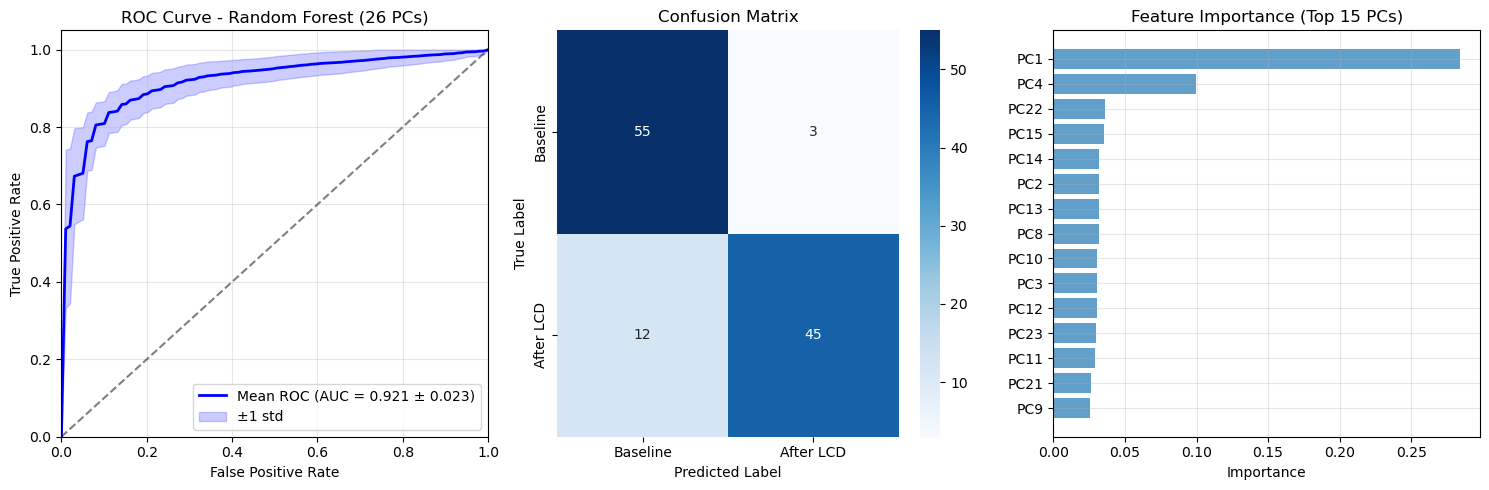

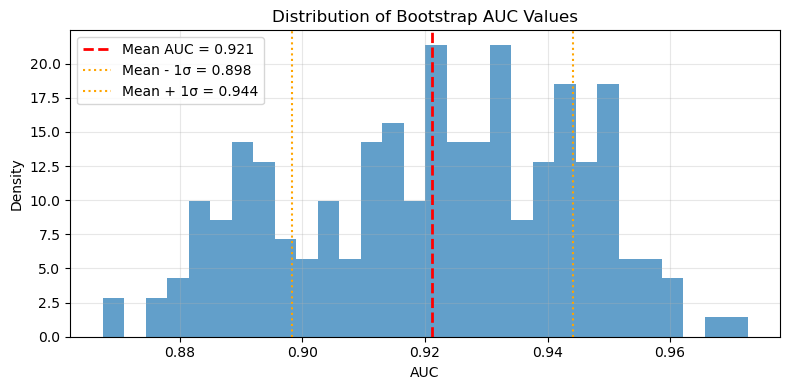


Final Results:
Random Forest Accuracy: 0.870
Random Forest AUC: 0.921 ± 0.023
Analysis saved to results/pathway/


In [25]:
# -------- Random Forest Classification with ROC Analysis (26 PCs) --------
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import numpy as np

print("=== Random Forest Classification with ROC Analysis (26 PCs) ===")

# Prepare data for classification
X_pca_26 = Z_aligned_26  # 26-component weighted PCA scores
y = sample_annot_aligned_26['group_0_1'].values
class_labels = ['Baseline', 'After LCD']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Data shape: X_pca={X_pca_26.shape}, y={len(y)}")
print(f"Classes: {class_labels}")
print(f"Class distribution: {pd.Series(y).value_counts()}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_26, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# Initialize Random Forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

print("\n--- Random Forest Training ---")
# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.3f}")

# Cross-validation
cv_scores = cross_val_score(rf, X_pca_26, y_encoded, cv=StratifiedKFold(5), scoring='accuracy')
print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_labels))

# -------- ROC Curve Analysis with Confidence Bands --------
print("\n=== ROC Curve Analysis with Confidence Bands ===")

# Bootstrap parameters
n_bootstraps = 200
n_folds = 5

# Store FPR/TPR for bootstrap samples
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

# Cross-validation with bootstrap for confidence bands
cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

print("Computing ROC curves with bootstrap sampling...")
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_pca_26, y)):
    X_train_cv, X_test_cv = X_pca_26[train_idx], X_pca_26[test_idx]
    y_train_cv, y_test_cv = y[train_idx], y[test_idx]
    
    # Bootstrap sampling within each fold
    n_boot_per_fold = n_bootstraps // n_folds
    for i in range(n_boot_per_fold):
        # Bootstrap sample from training set
        boot_idx = np.random.choice(len(X_train_cv), size=len(X_train_cv), replace=True)
        X_boot = X_train_cv[boot_idx]
        y_boot = y_train_cv[boot_idx]
        
        # Train classifier
        rf_boot = RandomForestClassifier(n_estimators=100, random_state=42+i)
        rf_boot.fit(X_boot, y_boot)
        
        # Predict probabilities on test set
        y_score = rf_boot.predict_proba(X_test_cv)[:, 1]
        
        # Compute ROC curve
        fpr, tpr, _ = roc_curve(y_test_cv, y_score)
        roc_auc = auc(fpr, tpr)
        
        # Interpolate to common FPR values
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc)
    
    print(f"  Completed fold {fold_idx + 1}/{n_folds}")

# Convert to arrays
tprs = np.array(tprs)
aucs = np.array(aucs)

# Compute mean and std
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

print(f"Random Forest AUC: {mean_auc:.3f} ± {std_auc:.3f}")

# Plotting
plt.figure(figsize=(15, 5))

# ROC curve with confidence bands
plt.subplot(1, 3, 1)
plt.plot(mean_fpr, mean_tpr, 
        label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})',
        linewidth=2, color='blue')
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, 
                alpha=0.2, color='blue', label='±1 std')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (26 PCs)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Confusion matrix
plt.subplot(1, 3, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Feature importance (top 15 PCs)
plt.subplot(1, 3, 3)
importances = rf.feature_importances_
pc_names = [f'PC{i+1}' for i in range(len(importances))]
# Show top 15 most important PCs
top_indices = np.argsort(importances)[-15:]
plt.barh(range(15), importances[top_indices], alpha=0.7)
plt.yticks(range(15), [pc_names[i] for i in top_indices])
plt.xlabel('Importance')
plt.title('Feature Importance (Top 15 PCs)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTDIR / "rf_26pcs_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

# AUC distribution plot
plt.figure(figsize=(8, 4))
plt.hist(aucs, bins=30, alpha=0.7, density=True)
plt.axvline(mean_auc, color='red', linestyle='--', linewidth=2, 
           label=f'Mean AUC = {mean_auc:.3f}')
plt.axvline(mean_auc - std_auc, color='orange', linestyle=':', 
           label=f'Mean - 1σ = {mean_auc - std_auc:.3f}')
plt.axvline(mean_auc + std_auc, color='orange', linestyle=':', 
           label=f'Mean + 1σ = {mean_auc + std_auc:.3f}')
plt.xlabel('AUC')
plt.ylabel('Density')
plt.title('Distribution of Bootstrap AUC Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTDIR / "rf_26pcs_auc_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFinal Results:")
print(f"Random Forest Accuracy: {accuracy:.3f}")
print(f"Random Forest AUC: {mean_auc:.3f} ± {std_auc:.3f}")
print(f"Analysis saved to results/pathway/")

In [26]:
def weighted_pca_rf_analysis(n_components, save_suffix=""):
    """
    Perform weighted PCA followed by Random Forest classification with ROC analysis
    
    Parameters:
    -----------
    n_components : int
        Number of principal components to use
    save_suffix : str
        Suffix to add to saved file names (e.g., "_15pcs")
    
    Returns:
    --------
    dict : Results dictionary containing accuracy, AUC, and other metrics
    """
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler, LabelEncoder
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    
    print(f"=== Weighted PCA with {n_components} Components ===")
    
    # -------- Weighted PCA --------
    # Align expression matrix with weights (both indexed by gene symbols)
    common_genes = list(set(expr_vst.index) & set(weights.index))
    expr_aligned = expr_vst.loc[common_genes]
    weights_aligned = weights.loc[common_genes, "final_weight"]
    
    # Standardize and weight
    X = expr_aligned.T.values  # transpose: samples x genes
    Xz = StandardScaler().fit_transform(X)
    sqrtw = np.sqrt(weights_aligned.values)
    Xw = Xz * sqrtw[None, :]
    
    # PCA
    pca = PCA(n_components=n_components, random_state=0)
    Z = pca.fit_transform(Xw)
    
    # Load and align sample annotation
    sample_annot = pd.read_csv("../results/GSE95640_sample_annotation.csv", index_col=0)
    pca_samples = set(expr_aligned.columns)
    annot_sample_names = set(sample_annot['sample_name'])
    common_samples = list(pca_samples & annot_sample_names)
    
    # Create mapping from sample_name to annotation
    sample_name_to_annot = sample_annot.set_index('sample_name')
    sample_annot_aligned = sample_name_to_annot.loc[common_samples]
    
    # Create PCA DataFrame with sample alignment
    pca_df = pd.DataFrame(Z, index=expr_aligned.columns)
    pca_df_aligned = pca_df.loc[common_samples]
    Z_aligned = pca_df_aligned.values
    
    # Add group annotations to PCA scores DataFrame
    pca_df_with_groups = pca_df_aligned.copy()
    pca_df_with_groups['group'] = sample_annot_aligned['group']
    pca_df_with_groups['group_0_1'] = sample_annot_aligned['group_0_1']
    
    # Save PCA scores with group annotations
    pca_df_with_groups.to_csv(OUTDIR / f"weighted_pca{save_suffix}_scores.csv")
    
    print(f"Using {len(common_genes)} genes")
    print(f"Data shape: {Z_aligned.shape}")
    print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.1%}")
    
    # -------- Random Forest Classification --------
    print(f"\n=== Random Forest Classification ({n_components} PCs) ===")
    
    # Prepare data for classification
    X_pca = Z_aligned
    y = sample_annot_aligned['group_0_1'].values
    class_labels = ['Baseline', 'After LCD']
    
    # Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    print(f"Data shape: X_pca={X_pca.shape}, y={len(y)}")
    print(f"Class distribution: {pd.Series(y).value_counts()}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_pca, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
    )
    
    # Initialize Random Forest classifier
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    
    # Train
    rf.fit(X_train, y_train)
    
    # Predict
    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1]
    
    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {accuracy:.3f}")
    
    # Cross-validation
    cv_scores = cross_val_score(rf, X_pca, y_encoded, cv=StratifiedKFold(5), scoring='accuracy')
    print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_labels))
    
    # -------- ROC Curve Analysis with Confidence Bands --------
    print("\n=== ROC Curve Analysis with Confidence Bands ===")
    
    # Bootstrap parameters
    n_bootstraps = 200
    n_folds = 5
    
    # Store FPR/TPR for bootstrap samples
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)
    
    # Cross-validation with bootstrap for confidence bands
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    print("Computing ROC curves with bootstrap sampling...")
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_pca, y)):
        X_train_cv, X_test_cv = X_pca[train_idx], X_pca[test_idx]
        y_train_cv, y_test_cv = y[train_idx], y[test_idx]
        
        # Bootstrap sampling within each fold
        n_boot_per_fold = n_bootstraps // n_folds
        for i in range(n_boot_per_fold):
            # Bootstrap sample from training set
            boot_idx = np.random.choice(len(X_train_cv), size=len(X_train_cv), replace=True)
            X_boot = X_train_cv[boot_idx]
            y_boot = y_train_cv[boot_idx]
            
            # Train classifier
            rf_boot = RandomForestClassifier(n_estimators=100, random_state=42+i)
            rf_boot.fit(X_boot, y_boot)
            
            # Predict probabilities on test set
            y_score = rf_boot.predict_proba(X_test_cv)[:, 1]
            
            # Compute ROC curve
            fpr, tpr, _ = roc_curve(y_test_cv, y_score)
            roc_auc = auc(fpr, tpr)
            
            # Interpolate to common FPR values
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            tprs.append(interp_tpr)
            aucs.append(roc_auc)
        
        if fold_idx == 0:  # Progress indicator
            print(f"  Completed fold {fold_idx + 1}/{n_folds}")
    
    # Convert to arrays
    tprs = np.array(tprs)
    aucs = np.array(aucs)
    
    # Compute mean and std
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    
    std_tpr = np.std(tprs, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
    
    print(f"Random Forest AUC: {mean_auc:.3f} ± {std_auc:.3f}")
    
    # Plotting
    plt.figure(figsize=(15, 5))
    
    # ROC curve with confidence bands
    plt.subplot(1, 3, 1)
    plt.plot(mean_fpr, mean_tpr, 
            label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})',
            linewidth=2, color='blue')
    plt.fill_between(mean_fpr, tprs_lower, tprs_upper, 
                    alpha=0.2, color='blue', label='±1 std')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - Random Forest ({n_components} PCs)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    
    # Confusion matrix
    plt.subplot(1, 3, 2)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    
    # Feature importance (top 15 PCs or all if fewer)
    plt.subplot(1, 3, 3)
    importances = rf.feature_importances_
    pc_names = [f'PC{i+1}' for i in range(len(importances))]
    # Show top components (max 15 or all available)
    n_show = min(15, len(importances))
    top_indices = np.argsort(importances)[-n_show:]
    plt.barh(range(n_show), importances[top_indices], alpha=0.7)
    plt.yticks(range(n_show), [pc_names[i] for i in top_indices])
    plt.xlabel('Importance')
    plt.title(f'Feature Importance (Top {n_show} PCs)')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTDIR / f"rf{save_suffix}_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    # Results summary
    results = {
        'n_components': n_components,
        'n_genes': len(common_genes),
        'explained_variance': pca.explained_variance_ratio_.sum(),
        'accuracy': accuracy,
        'cv_accuracy_mean': cv_scores.mean(),
        'cv_accuracy_std': cv_scores.std(),
        'auc_mean': mean_auc,
        'auc_std': std_auc,
        'confusion_matrix': cm,
        'feature_importance': importances
    }
    
    print(f"\nFinal Results:")
    print(f"Random Forest Accuracy: {accuracy:.3f}")
    print(f"Random Forest AUC: {mean_auc:.3f} ± {std_auc:.3f}")
    print(f"Explained Variance: {pca.explained_variance_ratio_.sum():.1%}")
    print(f"Analysis saved to results/pathway/")
    
    return results

print("Function 'weighted_pca_rf_analysis' created successfully!")

Function 'weighted_pca_rf_analysis' created successfully!


=== Weighted PCA with 10 Components ===
Using 80 genes
Data shape: (382, 10)
Total explained variance: 69.4%

=== Random Forest Classification (10 PCs) ===
Data shape: X_pca=(382, 10), y=382
Class distribution: 0    191
1    191
Name: count, dtype: int64
Test Accuracy: 0.904
CV Accuracy: 0.890 ± 0.021

Classification Report:
              precision    recall  f1-score   support

    Baseline       0.86      0.97      0.91        58
   After LCD       0.96      0.84      0.90        57

    accuracy                           0.90       115
   macro avg       0.91      0.90      0.90       115
weighted avg       0.91      0.90      0.90       115


=== ROC Curve Analysis with Confidence Bands ===
Computing ROC curves with bootstrap sampling...
  Completed fold 1/5
Random Forest AUC: 0.932 ± 0.022


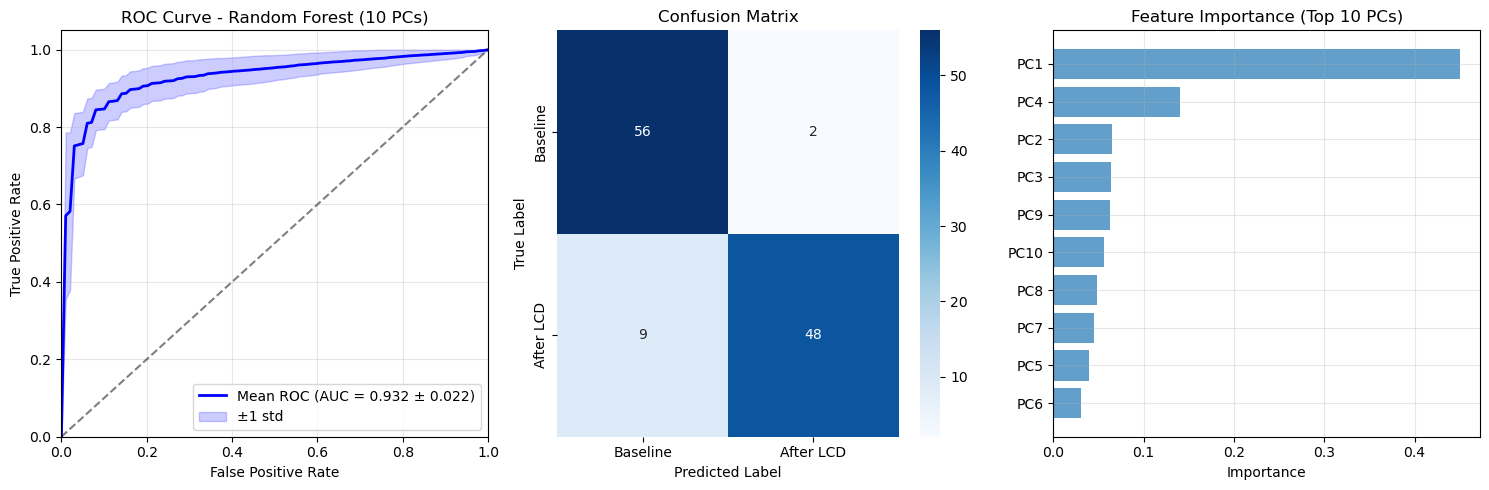


Final Results:
Random Forest Accuracy: 0.904
Random Forest AUC: 0.932 ± 0.022
Explained Variance: 69.4%
Analysis saved to results/pathway/


In [37]:
# Run weighted PCA and Random Forest analysis with 10 components
results_10 = weighted_pca_rf_analysis(n_components=10, save_suffix="_10pcs")

=== Weighted PCA with 13 Components ===
Using 80 genes
Data shape: (382, 13)
Total explained variance: 74.7%

=== Random Forest Classification (13 PCs) ===
Data shape: X_pca=(382, 13), y=382
Class distribution: 0    191
1    191
Name: count, dtype: int64
Test Accuracy: 0.878
CV Accuracy: 0.869 ± 0.032

Classification Report:
              precision    recall  f1-score   support

    Baseline       0.83      0.95      0.89        58
   After LCD       0.94      0.81      0.87        57

    accuracy                           0.88       115
   macro avg       0.89      0.88      0.88       115
weighted avg       0.89      0.88      0.88       115


=== ROC Curve Analysis with Confidence Bands ===
Computing ROC curves with bootstrap sampling...
CV Accuracy: 0.869 ± 0.032

Classification Report:
              precision    recall  f1-score   support

    Baseline       0.83      0.95      0.89        58
   After LCD       0.94      0.81      0.87        57

    accuracy                     

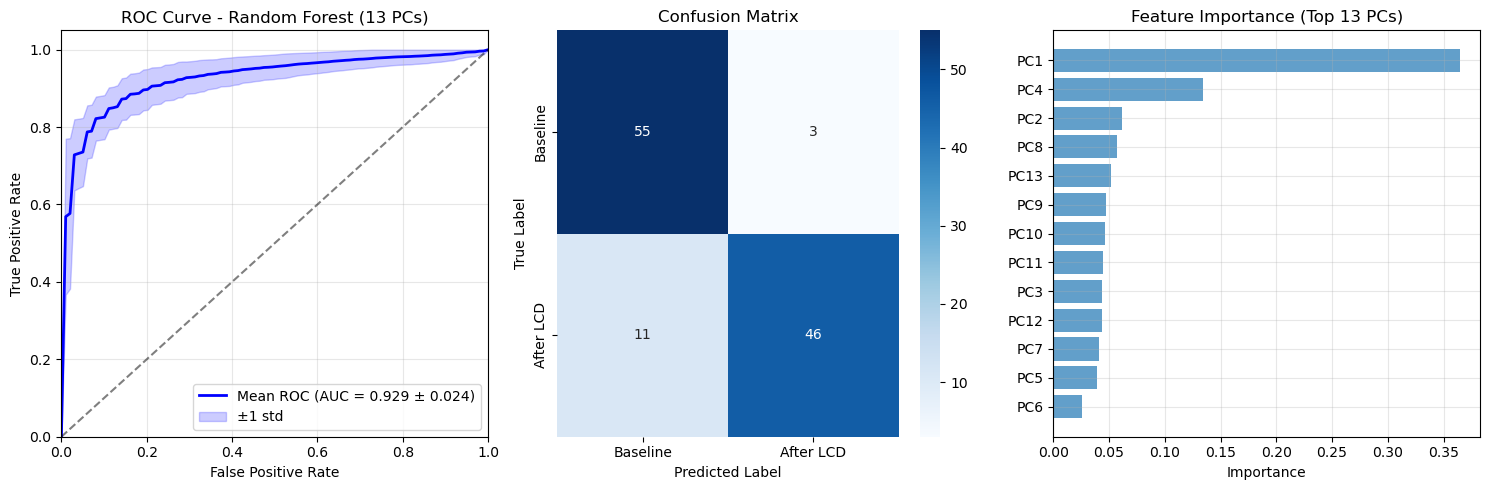


Final Results:
Random Forest Accuracy: 0.878
Random Forest AUC: 0.929 ± 0.024
Explained Variance: 74.7%
Analysis saved to results/pathway/


In [28]:
# Run weighted PCA and Random Forest analysis with 13 components
results_13 = weighted_pca_rf_analysis(n_components=13, save_suffix="_13pcs")

=== Weighted PCA with 5 Components ===
Using 80 genes
Data shape: (382, 5)
Total explained variance: 56.5%

=== Random Forest Classification (5 PCs) ===
Data shape: X_pca=(382, 5), y=382
Class distribution: 0    191
1    191
Name: count, dtype: int64
Test Accuracy: 0.896
CV Accuracy: 0.888 ± 0.021

Classification Report:
              precision    recall  f1-score   support

    Baseline       0.87      0.93      0.90        58
   After LCD       0.92      0.86      0.89        57

    accuracy                           0.90       115
   macro avg       0.90      0.90      0.90       115
weighted avg       0.90      0.90      0.90       115


=== ROC Curve Analysis with Confidence Bands ===
Computing ROC curves with bootstrap sampling...
CV Accuracy: 0.888 ± 0.021

Classification Report:
              precision    recall  f1-score   support

    Baseline       0.87      0.93      0.90        58
   After LCD       0.92      0.86      0.89        57

    accuracy                         

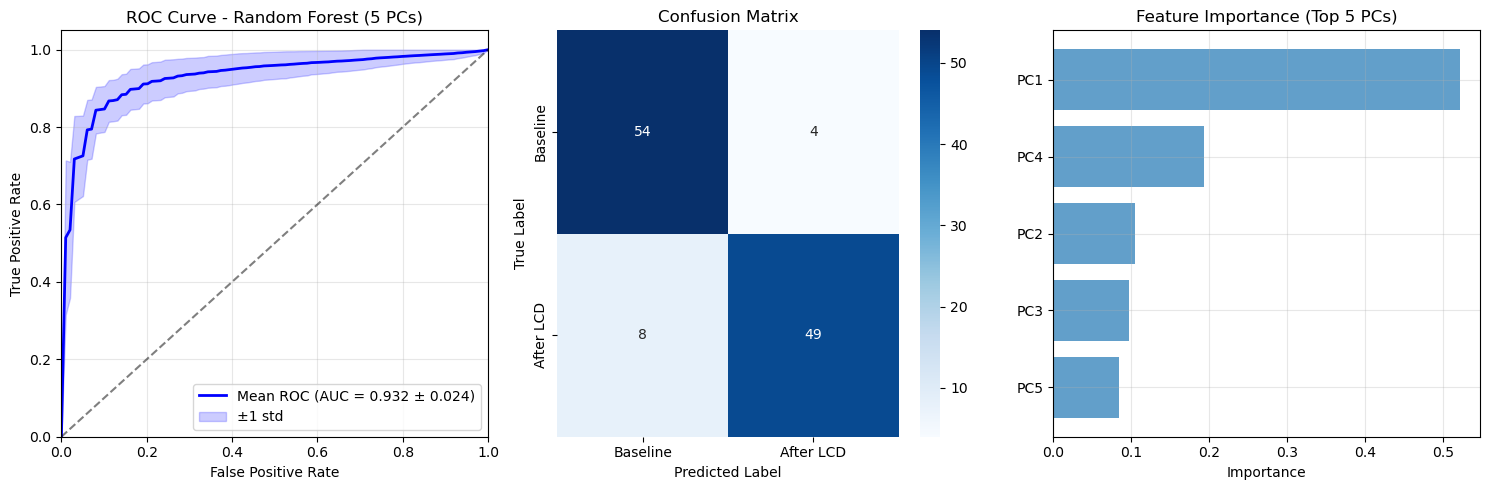


Final Results:
Random Forest Accuracy: 0.896
Random Forest AUC: 0.932 ± 0.024
Explained Variance: 56.5%
Analysis saved to results/pathway/

PCA scores CSV shape: (382, 7)
Columns: ['0', '1', '2', '3', '4', 'group', 'group_0_1']

First few rows:
                   0         1         2         3         4  \
GSM2520295  7.561755 -0.816275  1.401454  2.542893 -3.224365   
GSM2520355  0.723029  0.278088 -0.209402  0.092914 -0.328120   
GSM2520381 -3.494060 -0.037833 -0.547844  0.415958 -0.114760   
GSM2520274 -2.903476 -0.424312 -0.424244  1.250954  0.067143   
GSM2520324 -1.469527 -0.706043  0.376944  0.430462 -0.123910   

                                                 group  group_0_1  
GSM2520295  time: CID1 is for the baseline without LCD          0  
GSM2520355  time: CID1 is for the baseline without LCD          0  
GSM2520381          time: CID2 is after 8 weeks of LCD          1  
GSM2520274          time: CID2 is after 8 weeks of LCD          1  
GSM2520324          time: CID

In [29]:
# Test the updated function with 5 components to verify group annotations are included
results_5 = weighted_pca_rf_analysis(n_components=5, save_suffix="_5pcs")

# Verify the CSV file contains group annotations
pca_scores_with_groups = pd.read_csv(OUTDIR / "weighted_pca_5pcs_scores.csv", index_col=0)
print(f"\nPCA scores CSV shape: {pca_scores_with_groups.shape}")
print(f"Columns: {list(pca_scores_with_groups.columns)}")
print(f"\nFirst few rows:")
print(pca_scores_with_groups.head())

=== Weighted PCA with 26 Components ===
Using 80 genes
Data shape: (382, 26)
Total explained variance: 87.6%

=== Random Forest Classification (26 PCs) ===
Data shape: X_pca=(382, 26), y=382
Class distribution: 0    191
1    191
Name: count, dtype: int64
Test Accuracy: 0.870
CV Accuracy: 0.859 ± 0.037

Classification Report:
              precision    recall  f1-score   support

    Baseline       0.82      0.95      0.88        58
   After LCD       0.94      0.79      0.86        57

    accuracy                           0.87       115
   macro avg       0.88      0.87      0.87       115
weighted avg       0.88      0.87      0.87       115


=== ROC Curve Analysis with Confidence Bands ===
Computing ROC curves with bootstrap sampling...
  Completed fold 1/5
Random Forest AUC: 0.925 ± 0.025


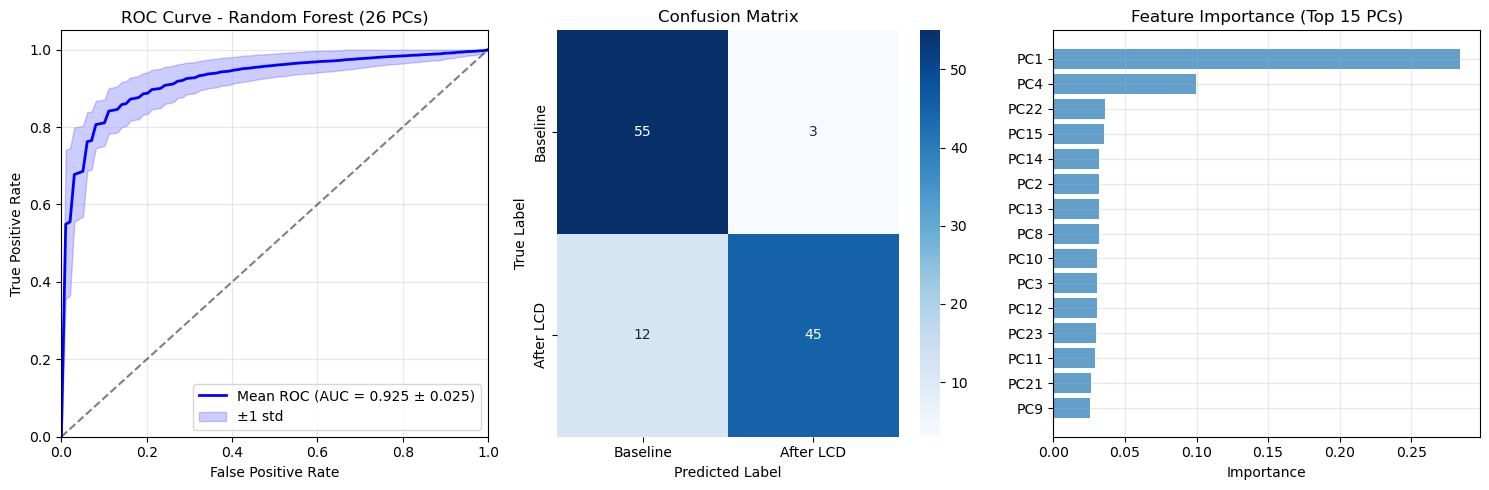


Final Results:
Random Forest Accuracy: 0.870
Random Forest AUC: 0.925 ± 0.025
Explained Variance: 87.6%
Analysis saved to results/pathway/


In [38]:
# Run weighted PCA and Random Forest analysis with 26 components
results_26 = weighted_pca_rf_analysis(n_components=26, save_suffix="_26pcs")

In [30]:
# -------- Network Visualization --------
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd

print("=== Creating Network Visualizations ===")

# Load the pathway and adjacency data
pathways_file = OUTDIR / "pathways_dict.json"
adjacency_file = OUTDIR / "gene_adjacency_jaccard.csv"
incidence_file = OUTDIR / "gene_pathway_incidence.csv"
weights_file = OUTDIR / "gene_weights.csv"

if pathways_file.exists() and adjacency_file.exists():
    # Load data
    with open(pathways_file, 'r') as f:
        pathways_dict = json.load(f)
    
    adj_matrix = pd.read_csv(adjacency_file, index_col=0)
    incidence_matrix = pd.read_csv(incidence_file, index_col=0)
    gene_weights = pd.read_csv(weights_file, index_col=0)
    
    print(f"Loaded {len(pathways_dict)} pathways")
    print(f"Adjacency matrix shape: {adj_matrix.shape}")
    print(f"Gene-pathway incidence shape: {incidence_matrix.shape}")
    
else:
    print("Required files not found. Please run the pathway analysis first.")

=== Creating Network Visualizations ===
Loaded 15 pathways
Adjacency matrix shape: (80, 80)
Gene-pathway incidence shape: (80, 15)


Creating gene-gene network...
Gene network: 40 nodes, 30 edges


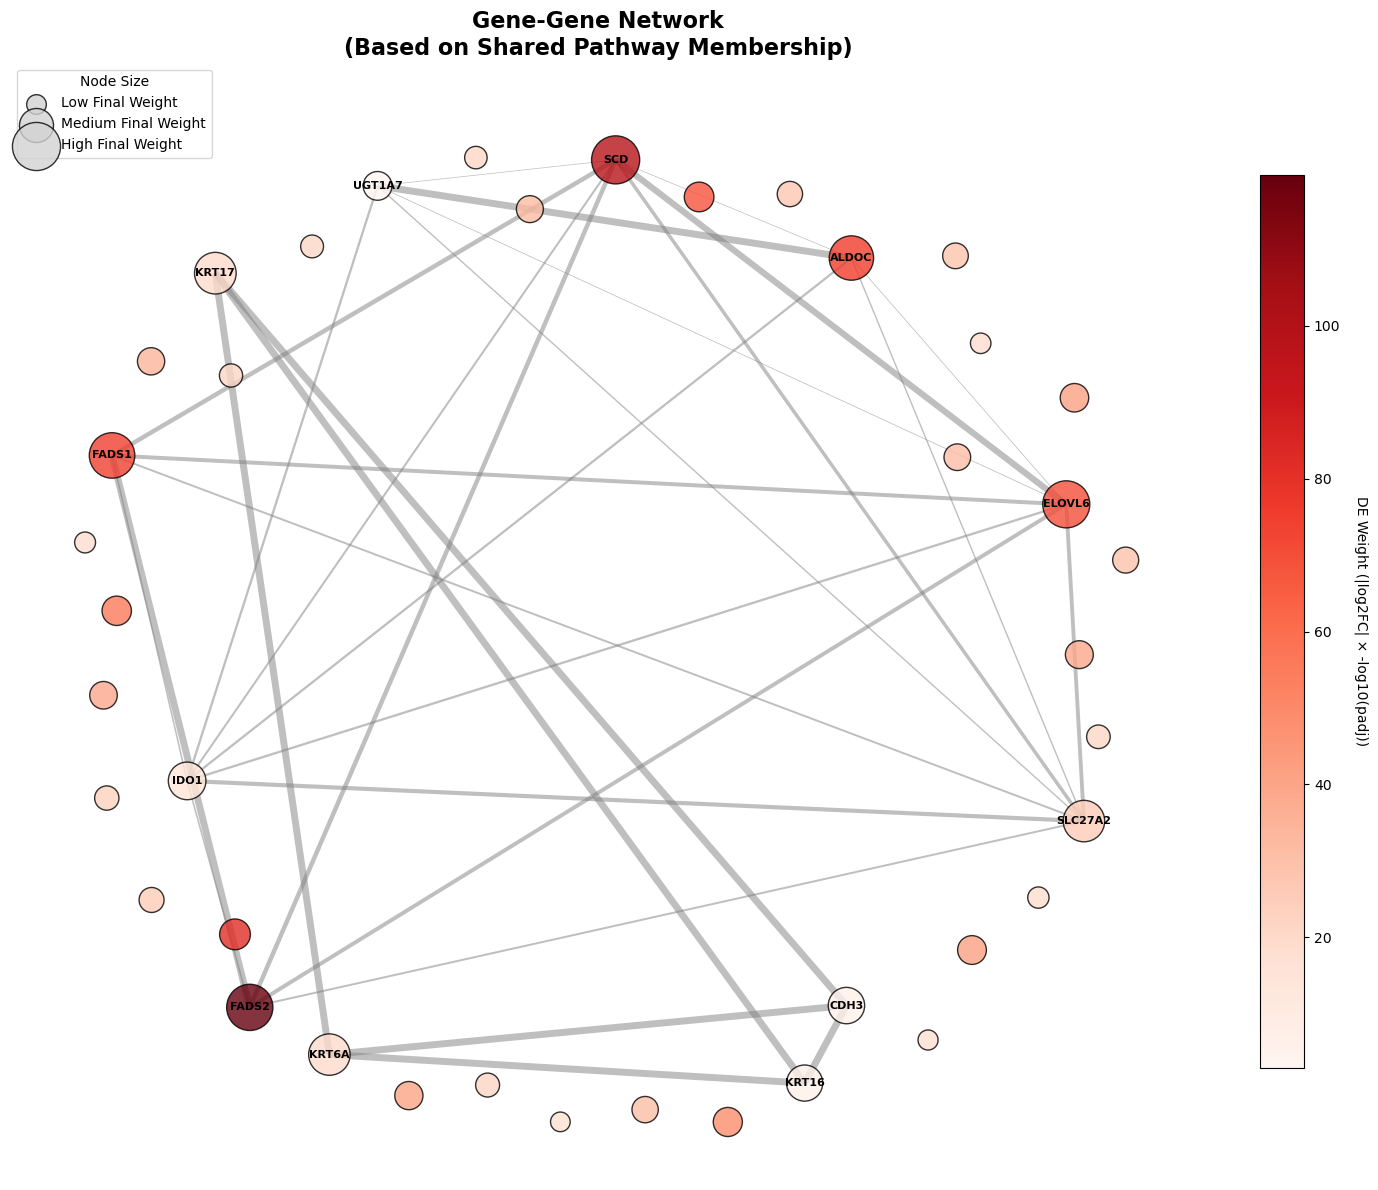


Network Statistics:
  Number of nodes: 40
  Number of edges: 30
  Average degree: 1.50
  Network density: 0.038
  Number of connected components: 30

Top 10 most connected genes:
  SCD: degree=7, centrality=0.179
  ELOVL6: degree=7, centrality=0.179
  SLC27A2: degree=7, centrality=0.179
  IDO1: degree=7, centrality=0.179
  FADS2: degree=5, centrality=0.128
  FADS1: degree=5, centrality=0.128
  ALDOC: degree=5, centrality=0.128
  UGT1A7: degree=5, centrality=0.128
  KRT17: degree=3, centrality=0.077
  KRT6A: degree=3, centrality=0.077


In [31]:
# -------- 1. Gene-Gene Network (Based on Pathway Similarity) --------
def create_gene_network(adj_matrix, gene_weights, threshold=0.1, max_nodes=50):
    """
    Create a gene-gene network based on pathway similarity (Jaccard index)
    """
    # Filter by threshold to reduce edge density
    adj_filtered = adj_matrix.copy()
    adj_filtered[adj_filtered < threshold] = 0
    
    # Select top genes by final weight for visualization
    top_genes = gene_weights.nlargest(max_nodes, 'final_weight').index
    adj_subset = adj_filtered.loc[top_genes, top_genes]
    
    # Create NetworkX graph
    G = nx.Graph()
    
    # Add nodes with attributes
    for gene in top_genes:
        G.add_node(gene, 
                  weight=gene_weights.loc[gene, 'final_weight'],
                  de_weight=gene_weights.loc[gene, 'de_weight'],
                  centrality=gene_weights.loc[gene, 'centrality'])
    
    # Add edges
    for i in range(len(top_genes)):
        for j in range(i+1, len(top_genes)):
            gene1, gene2 = top_genes[i], top_genes[j]
            weight = adj_subset.loc[gene1, gene2]
            if weight > 0:
                G.add_edge(gene1, gene2, weight=weight)
    
    return G, adj_subset

# Create gene network
print("Creating gene-gene network...")
gene_network, adj_subset = create_gene_network(adj_matrix, gene_weights, threshold=0.1, max_nodes=40)

print(f"Gene network: {gene_network.number_of_nodes()} nodes, {gene_network.number_of_edges()} edges")

# Plot gene network
plt.figure(figsize=(15, 12))

# Use spring layout for better visualization
pos = nx.spring_layout(gene_network, k=3, iterations=50, seed=42)

# Node sizes based on final weights
node_weights = [gene_weights.loc[node, 'final_weight'] for node in gene_network.nodes()]
node_sizes = [(w - min(node_weights)) / (max(node_weights) - min(node_weights)) * 1000 + 200 
              for w in node_weights]

# Node colors based on DE weights
de_weights = [gene_weights.loc[node, 'de_weight'] for node in gene_network.nodes()]
node_colors = de_weights

# Edge widths based on Jaccard similarity
edge_weights = [gene_network[u][v]['weight'] for u, v in gene_network.edges()]
edge_widths = [(w * 5) for w in edge_weights]

# Draw network
nx.draw_networkx_nodes(gene_network, pos, 
                      node_size=node_sizes,
                      node_color=node_colors,
                      cmap='Reds',
                      alpha=0.8,
                      edgecolors='black',
                      linewidths=1)

nx.draw_networkx_edges(gene_network, pos,
                      width=edge_widths,
                      alpha=0.5,
                      edge_color='gray')

# Add labels for highly connected nodes
high_degree_nodes = [node for node, degree in gene_network.degree() if degree >= 3]
labels = {node: node for node in high_degree_nodes}
nx.draw_networkx_labels(gene_network, pos, labels, font_size=8, font_weight='bold')

plt.title('Gene-Gene Network\n(Based on Shared Pathway Membership)', size=16, fontweight='bold')
plt.axis('off')

# Add colorbar for DE weights
sm = plt.cm.ScalarMappable(cmap='Reds', 
                          norm=plt.Normalize(vmin=min(de_weights), vmax=max(de_weights)))
sm.set_array([])
cbar = plt.colorbar(sm, shrink=0.8, ax=plt.gca())
cbar.set_label('DE Weight (|log2FC| × -log10(padj))', rotation=270, labelpad=20)

# Add legend for node sizes
legend_sizes = [200, 600, 1200]
legend_labels = ['Low', 'Medium', 'High']
legend_nodes = []
for i, (size, label) in enumerate(zip(legend_sizes, legend_labels)):
    legend_nodes.append(plt.scatter([], [], s=size, c='lightgray', alpha=0.8, 
                                   edgecolors='black', linewidths=1, label=f'{label} Final Weight'))
plt.legend(handles=legend_nodes, loc='upper left', title='Node Size')

plt.tight_layout()
plt.savefig(OUTDIR / "gene_network.png", dpi=300, bbox_inches='tight')
plt.show()

# Network statistics
print(f"\nNetwork Statistics:")
print(f"  Number of nodes: {gene_network.number_of_nodes()}")
print(f"  Number of edges: {gene_network.number_of_edges()}")
print(f"  Average degree: {np.mean([d for n, d in gene_network.degree()]):.2f}")
print(f"  Network density: {nx.density(gene_network):.3f}")
print(f"  Number of connected components: {nx.number_connected_components(gene_network)}")

# Top connected genes
degree_centrality = nx.degree_centrality(gene_network)
top_connected = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print(f"\nTop 10 most connected genes:")
for gene, centrality in top_connected:
    degree = gene_network.degree(gene)
    print(f"  {gene}: degree={degree}, centrality={centrality:.3f}")

Creating gene-pathway bipartite network...
Bipartite network: 37 nodes, 53 edges


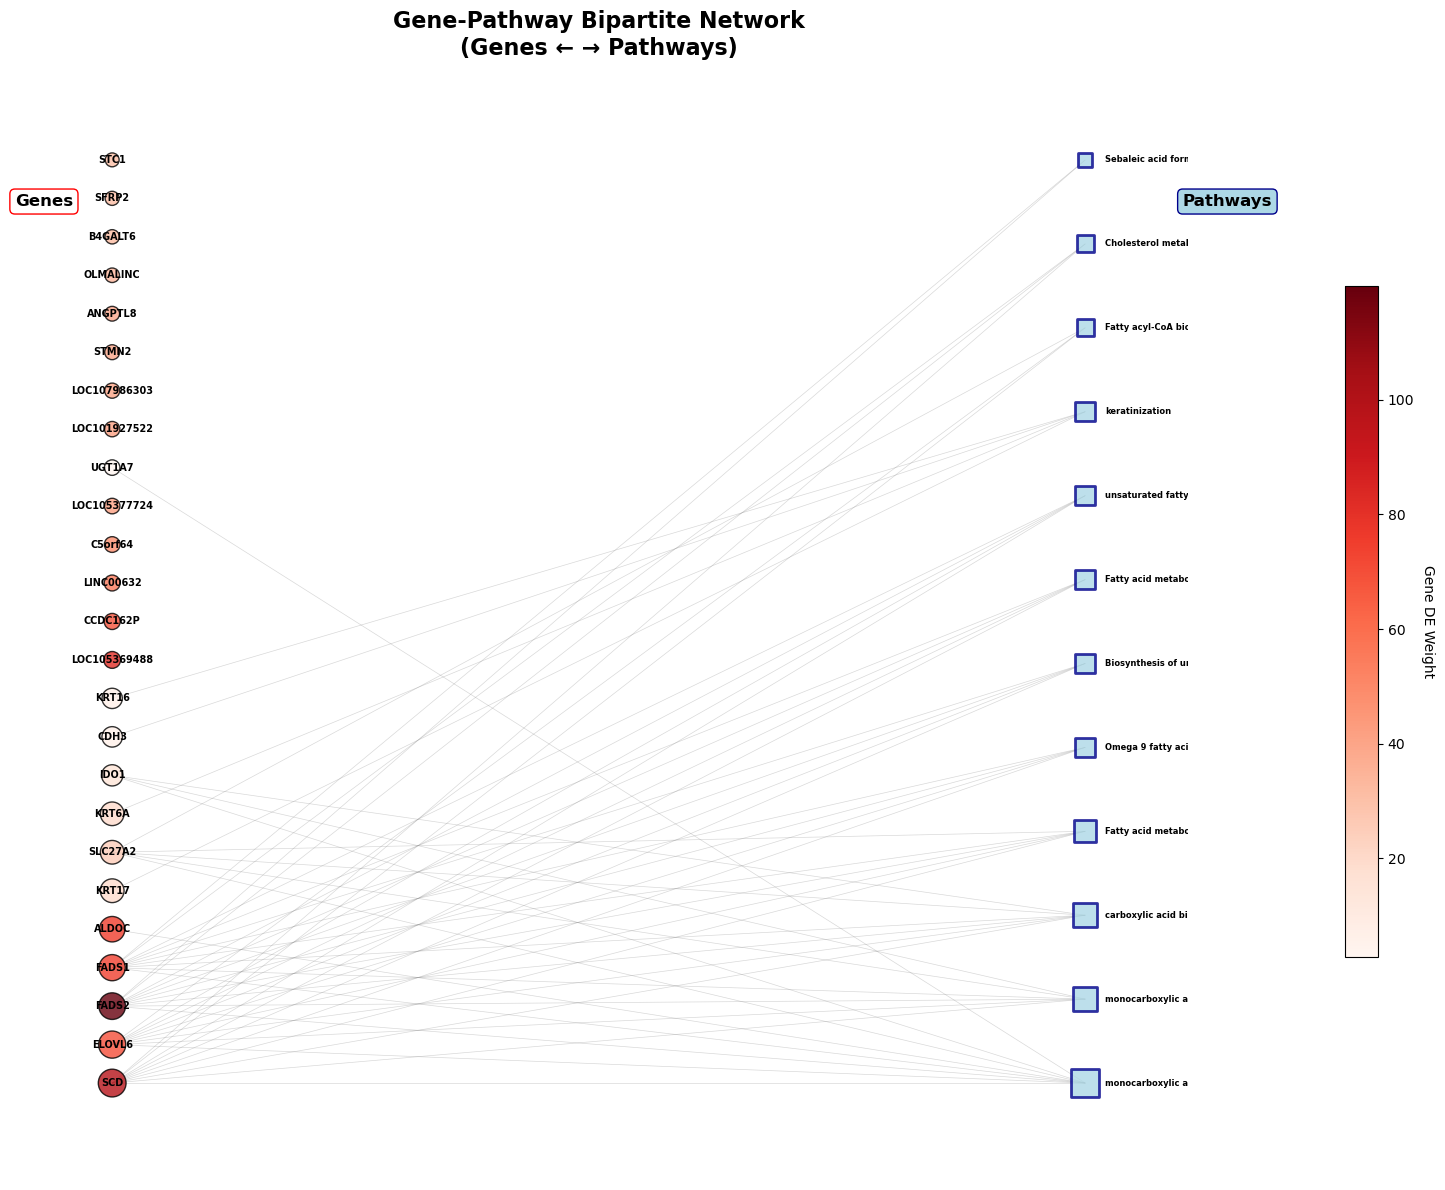


Top pathways by gene connectivity:
  monocarboxylic acid metabol...: 8 genes
  monocarboxylic acid biosynt...: 6 genes
  carboxylic acid biosyntheti...: 6 genes
  Fatty acid metabolism: 5 genes
  Omega 9 fatty acid synthesis: 4 genes
  Biosynthesis of unsaturated...: 4 genes
  Fatty acid metabolism: 4 genes
  unsaturated fatty acid bios...: 4 genes
  keratinization: 4 genes
  Fatty acyl-CoA biosynthesis: 3 genes
  Cholesterol metabolism with...: 3 genes
  Sebaleic acid formation and...: 2 genes


In [32]:
# -------- 2. Bipartite Gene-Pathway Network --------
def create_bipartite_network(incidence_matrix, gene_weights, pathways_dict, 
                            max_genes=30, max_pathways=15):
    """
    Create a bipartite network showing gene-pathway relationships
    """
    # Select top genes and pathways
    top_genes = gene_weights.nlargest(max_genes, 'final_weight').index
    
    # Select pathways with most connections to top genes
    pathway_connections = incidence_matrix.loc[top_genes].sum(axis=0)
    top_pathways = pathway_connections.nlargest(max_pathways).index
    
    # Create bipartite graph
    B = nx.Graph()
    
    # Add gene nodes
    for gene in top_genes:
        B.add_node(gene, bipartite=0, node_type='gene',
                  weight=gene_weights.loc[gene, 'final_weight'],
                  de_weight=gene_weights.loc[gene, 'de_weight'])
    
    # Add pathway nodes
    for pathway in top_pathways:
        # Extract pathway name (after the '|' separator)
        pathway_name = pathway.split('|')[-1] if '|' in pathway else pathway
        # Truncate long names
        if len(pathway_name) > 30:
            pathway_name = pathway_name[:27] + '...'
        
        B.add_node(pathway, bipartite=1, node_type='pathway',
                  display_name=pathway_name,
                  n_genes=pathway_connections[pathway])
    
    # Add edges (gene-pathway connections)
    for gene in top_genes:
        for pathway in top_pathways:
            if incidence_matrix.loc[gene, pathway] == 1:
                B.add_edge(gene, pathway)
    
    return B, top_genes, top_pathways

# Create bipartite network
print("Creating gene-pathway bipartite network...")
bipartite_net, top_genes_bp, top_pathways_bp = create_bipartite_network(
    incidence_matrix, gene_weights, pathways_dict, max_genes=25, max_pathways=12)

print(f"Bipartite network: {bipartite_net.number_of_nodes()} nodes, {bipartite_net.number_of_edges()} edges")

# Plot bipartite network
plt.figure(figsize=(16, 12))

# Separate gene and pathway nodes
gene_nodes = [n for n, d in bipartite_net.nodes(data=True) if d['node_type'] == 'gene']
pathway_nodes = [n for n, d in bipartite_net.nodes(data=True) if d['node_type'] == 'pathway']

# Create layout
pos = {}

# Position genes on the left
gene_y_positions = np.linspace(0, 1, len(gene_nodes))
for i, gene in enumerate(gene_nodes):
    pos[gene] = (0, gene_y_positions[i])

# Position pathways on the right
pathway_y_positions = np.linspace(0, 1, len(pathway_nodes))
for i, pathway in enumerate(pathway_nodes):
    pos[pathway] = (1, pathway_y_positions[i])

# Node sizes and colors for genes
gene_weights_bp = [gene_weights.loc[gene, 'final_weight'] for gene in gene_nodes]
gene_sizes = [(w - min(gene_weights_bp)) / (max(gene_weights_bp) - min(gene_weights_bp)) * 300 + 100 
              for w in gene_weights_bp]

gene_de_weights = [gene_weights.loc[gene, 'de_weight'] for gene in gene_nodes]

# Node sizes for pathways based on number of connected genes
pathway_connections_bp = [bipartite_net.degree(pathway) for pathway in pathway_nodes]
pathway_sizes = [(c - min(pathway_connections_bp)) / (max(pathway_connections_bp) - min(pathway_connections_bp)) * 300 + 100 
                 for c in pathway_connections_bp]

# Draw gene nodes
nx.draw_networkx_nodes(bipartite_net, pos, 
                      nodelist=gene_nodes,
                      node_size=gene_sizes,
                      node_color=gene_de_weights,
                      cmap='Reds',
                      alpha=0.8,
                      node_shape='o',
                      edgecolors='black',
                      linewidths=1)

# Draw pathway nodes
nx.draw_networkx_nodes(bipartite_net, pos,
                      nodelist=pathway_nodes,
                      node_size=pathway_sizes,
                      node_color='lightblue',
                      alpha=0.8,
                      node_shape='s',
                      edgecolors='darkblue',
                      linewidths=2)

# Draw edges
nx.draw_networkx_edges(bipartite_net, pos,
                      alpha=0.3,
                      edge_color='gray',
                      width=0.5)

# Add labels for genes
gene_labels = {gene: gene for gene in gene_nodes}
nx.draw_networkx_labels(bipartite_net, pos, gene_labels, font_size=7, font_weight='bold')

# Add labels for pathways
pathway_labels = {pathway: bipartite_net.nodes[pathway]['display_name'] 
                 for pathway in pathway_nodes}
pathway_pos = {pathway: (pos[pathway][0] + 0.02, pos[pathway][1]) for pathway in pathway_nodes}
nx.draw_networkx_labels(bipartite_net, pathway_pos, pathway_labels, 
                       font_size=6, font_weight='bold', horizontalalignment='left')

plt.title('Gene-Pathway Bipartite Network\n(Genes ← → Pathways)', size=16, fontweight='bold')
plt.axis('off')

# Add legend
plt.text(-0.1, 0.95, 'Genes', fontsize=12, fontweight='bold', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="red"))
plt.text(1.1, 0.95, 'Pathways', fontsize=12, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", edgecolor="darkblue"))

# Add colorbar for gene DE weights
sm = plt.cm.ScalarMappable(cmap='Reds', 
                          norm=plt.Normalize(vmin=min(gene_de_weights), vmax=max(gene_de_weights)))
sm.set_array([])
cbar = plt.colorbar(sm, shrink=0.6, pad=0.1, ax=plt.gca())
cbar.set_label('Gene DE Weight', rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig(OUTDIR / "gene_pathway_bipartite.png", dpi=300, bbox_inches='tight')
plt.show()

# Print pathway information
print(f"\nTop pathways by gene connectivity:")
pathway_info = [(pathway, bipartite_net.degree(pathway), 
                bipartite_net.nodes[pathway]['display_name']) 
               for pathway in pathway_nodes]
pathway_info.sort(key=lambda x: x[1], reverse=True)

for pathway, degree, name in pathway_info:
    print(f"  {name}: {degree} genes")

Creating pathway similarity network...
Pathway network: 9 nodes, 28 edges


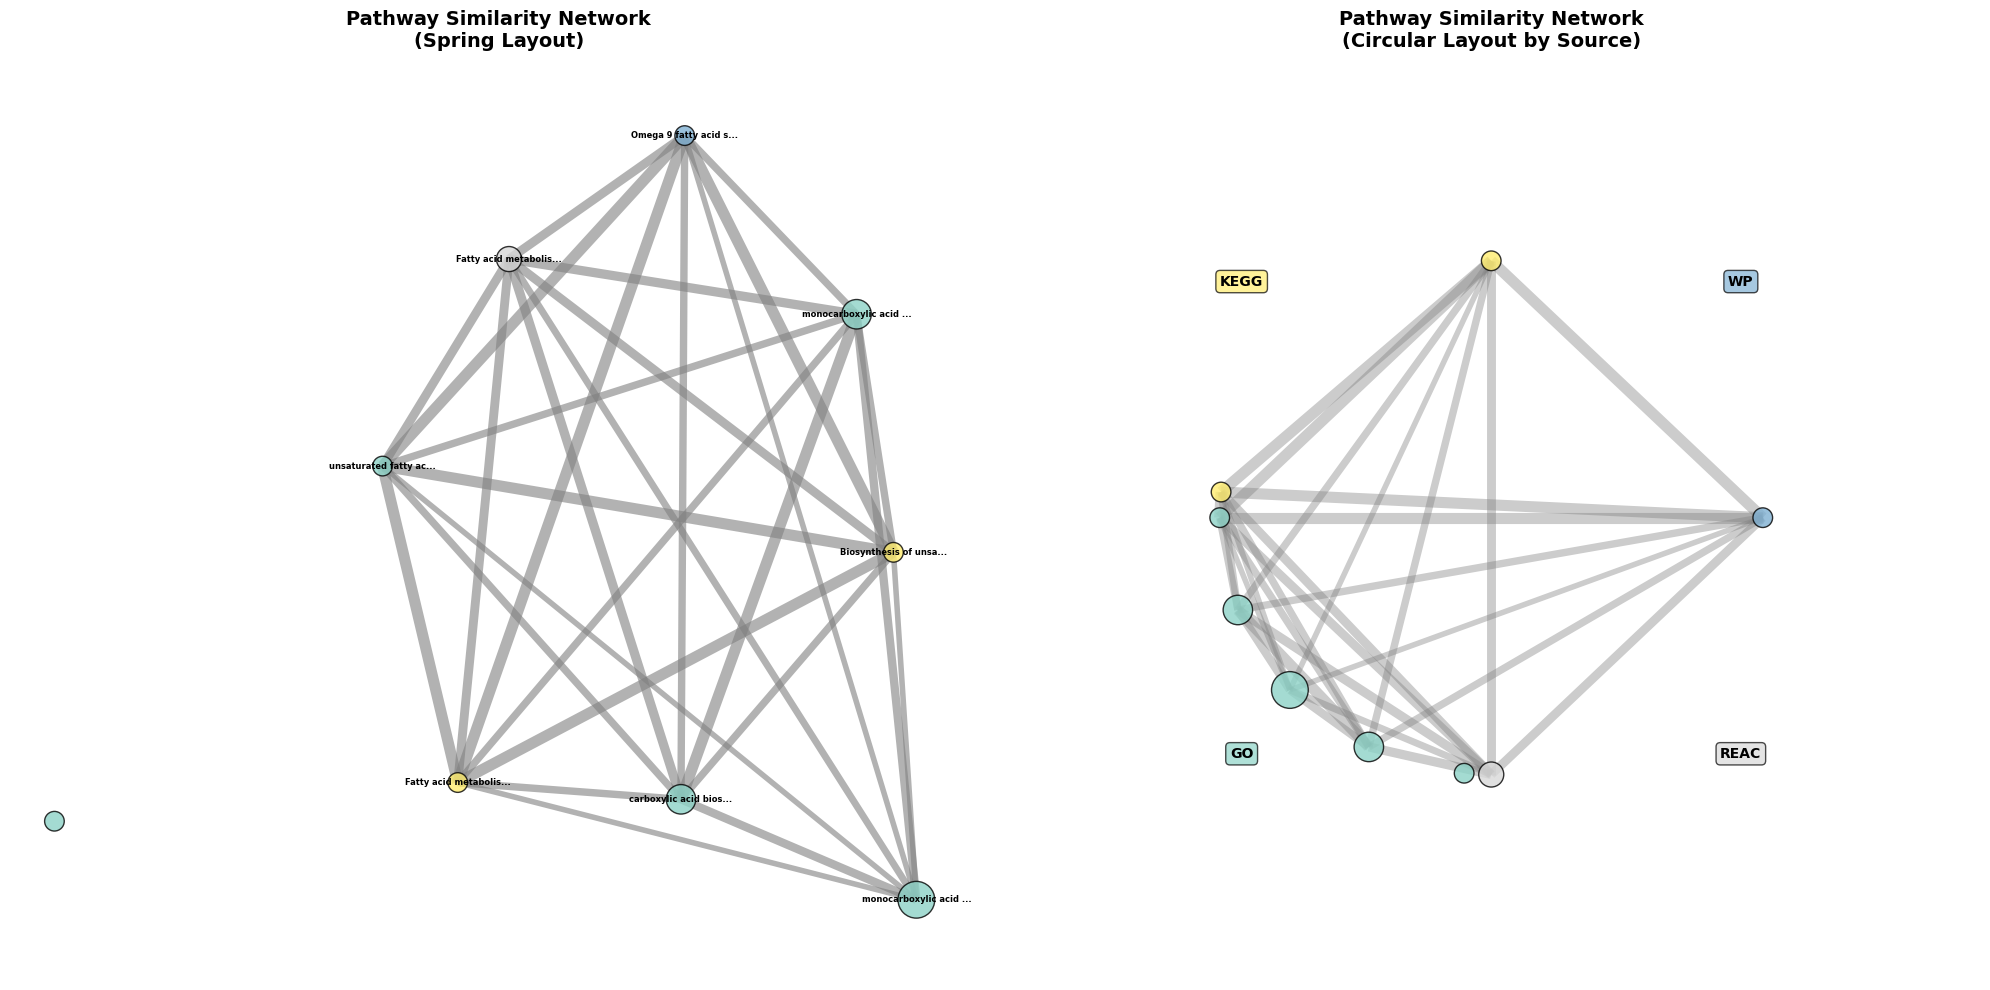


Pathway Network Statistics:
  Number of pathways: 9
  Number of connections: 28
  Average degree: 6.22
  Network density: 0.778

Top connected pathways:
  Omega 9 fatty acid s... (WP): degree=7, centrality=0.875
  Biosynthesis of unsa... (KEGG): degree=7, centrality=0.875
  Fatty acid metabolis... (KEGG): degree=7, centrality=0.875
  unsaturated fatty ac... (GO): degree=7, centrality=0.875
  monocarboxylic acid ... (GO): degree=7, centrality=0.875
  Fatty acid metabolis... (REAC): degree=7, centrality=0.875
  monocarboxylic acid ... (GO): degree=7, centrality=0.875
  carboxylic acid bios... (GO): degree=7, centrality=0.875

Pathway sources:
  GO: 5 pathways
  KEGG: 2 pathways
  WP: 1 pathways
  REAC: 1 pathways


In [33]:
# -------- 3. Pathway Similarity Network --------
def create_pathway_similarity_network(incidence_matrix, pathways_dict, min_genes=3, min_similarity=0.1):
    """
    Create a network of pathways connected by gene overlap similarity
    """
    # Filter pathways with sufficient genes
    pathway_gene_counts = incidence_matrix.sum(axis=0)
    filtered_pathways = pathway_gene_counts[pathway_gene_counts >= min_genes].index
    
    # Calculate pathway-pathway similarity (Jaccard index)
    P = nx.Graph()
    
    for i, pw1 in enumerate(filtered_pathways):
        # Extract short name for display
        pw1_name = pw1.split('|')[-1] if '|' in pw1 else pw1
        pw1_name = pw1_name[:20] + '...' if len(pw1_name) > 20 else pw1_name
        
        P.add_node(pw1, display_name=pw1_name, 
                  n_genes=pathway_gene_counts[pw1],
                  source=pw1.split(':')[0] if ':' in pw1 else 'Unknown')
        
        for j, pw2 in enumerate(filtered_pathways):
            if i < j:  # Avoid duplicates
                # Get genes in each pathway
                genes1 = set(incidence_matrix.index[incidence_matrix[pw1] == 1])
                genes2 = set(incidence_matrix.index[incidence_matrix[pw2] == 1])
                
                # Calculate Jaccard similarity
                intersection = len(genes1 & genes2)
                union = len(genes1 | genes2)
                
                if union > 0:
                    similarity = intersection / union
                    if similarity >= min_similarity:
                        P.add_edge(pw1, pw2, weight=similarity, shared_genes=intersection)
    
    return P, filtered_pathways

# Create pathway similarity network
print("Creating pathway similarity network...")
pathway_net, filtered_pathways = create_pathway_similarity_network(
    incidence_matrix, pathways_dict, min_genes=4, min_similarity=0.15)

print(f"Pathway network: {pathway_net.number_of_nodes()} nodes, {pathway_net.number_of_edges()} edges")

# Plot pathway network
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# ---- Left plot: Spring layout ----
plt.sca(ax1)
pos = nx.spring_layout(pathway_net, k=2, iterations=50, seed=42)

# Node sizes based on number of genes
node_gene_counts = [pathway_net.nodes[node]['n_genes'] for node in pathway_net.nodes()]
node_sizes = [(c - min(node_gene_counts)) / (max(node_gene_counts) - min(node_gene_counts)) * 500 + 200 
              for c in node_gene_counts]

# Node colors based on data source
sources = [pathway_net.nodes[node]['source'] for node in pathway_net.nodes()]
unique_sources = list(set(sources))
source_colors = plt.cm.Set3(np.linspace(0, 1, len(unique_sources)))
source_color_map = dict(zip(unique_sources, source_colors))
node_colors = [source_color_map[source] for source in sources]

# Edge widths based on similarity
edge_weights = [pathway_net[u][v]['weight'] for u, v in pathway_net.edges()]
edge_widths = [(w * 8) for w in edge_weights]

# Draw nodes
nx.draw_networkx_nodes(pathway_net, pos,
                      node_size=node_sizes,
                      node_color=node_colors,
                      alpha=0.8,
                      edgecolors='black',
                      linewidths=1)

# Draw edges
nx.draw_networkx_edges(pathway_net, pos,
                      width=edge_widths,
                      alpha=0.6,
                      edge_color='gray')

# Add labels for high-degree nodes
high_degree = [node for node, degree in pathway_net.degree() if degree >= 2]
labels = {node: pathway_net.nodes[node]['display_name'] for node in high_degree}
nx.draw_networkx_labels(pathway_net, pos, labels, font_size=6, font_weight='bold')

ax1.set_title('Pathway Similarity Network\n(Spring Layout)', size=14, fontweight='bold')
ax1.axis('off')

# ---- Right plot: Circular layout by source ----
plt.sca(ax2)

# Group nodes by source for circular layout
source_groups = {}
for node in pathway_net.nodes():
    source = pathway_net.nodes[node]['source']
    if source not in source_groups:
        source_groups[source] = []
    source_groups[source].append(node)

# Create circular positions grouped by source
pos_circular = {}
start_angle = 0
angle_per_source = 2 * np.pi / len(source_groups)

for source, nodes in source_groups.items():
    end_angle = start_angle + angle_per_source
    angles = np.linspace(start_angle, end_angle - 0.1, len(nodes))
    
    for i, node in enumerate(nodes):
        pos_circular[node] = (np.cos(angles[i]), np.sin(angles[i]))
    
    # Add source label
    mid_angle = (start_angle + end_angle) / 2
    label_pos = (1.3 * np.cos(mid_angle), 1.3 * np.sin(mid_angle))
    ax2.text(label_pos[0], label_pos[1], source, fontsize=10, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor=source_color_map[source], alpha=0.7))
    
    start_angle = end_angle

# Draw circular network
nx.draw_networkx_nodes(pathway_net, pos_circular,
                      node_size=node_sizes,
                      node_color=node_colors,
                      alpha=0.8,
                      edgecolors='black',
                      linewidths=1)

nx.draw_networkx_edges(pathway_net, pos_circular,
                      width=edge_widths,
                      alpha=0.4,
                      edge_color='gray')

ax2.set_title('Pathway Similarity Network\n(Circular Layout by Source)', size=14, fontweight='bold')
ax2.axis('off')
ax2.set_xlim(-1.8, 1.8)
ax2.set_ylim(-1.8, 1.8)

plt.tight_layout()
plt.savefig(OUTDIR / "pathway_similarity_network.png", dpi=300, bbox_inches='tight')
plt.show()

# Network statistics
print(f"\nPathway Network Statistics:")
print(f"  Number of pathways: {pathway_net.number_of_nodes()}")
print(f"  Number of connections: {pathway_net.number_of_edges()}")
print(f"  Average degree: {np.mean([d for n, d in pathway_net.degree()]):.2f}")
print(f"  Network density: {nx.density(pathway_net):.3f}")

# Top connected pathways
degree_centrality_pw = nx.degree_centrality(pathway_net)
top_connected_pw = sorted(degree_centrality_pw.items(), key=lambda x: x[1], reverse=True)[:8]
print(f"\nTop connected pathways:")
for pathway, centrality in top_connected_pw:
    degree = pathway_net.degree(pathway)
    name = pathway_net.nodes[pathway]['display_name']
    source = pathway_net.nodes[pathway]['source']
    print(f"  {name} ({source}): degree={degree}, centrality={centrality:.3f}")

# Source distribution
source_counts = {}
for node in pathway_net.nodes():
    source = pathway_net.nodes[node]['source']
    source_counts[source] = source_counts.get(source, 0) + 1

print(f"\nPathway sources:")
for source, count in sorted(source_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {source}: {count} pathways")

Creating network summary dashboard...


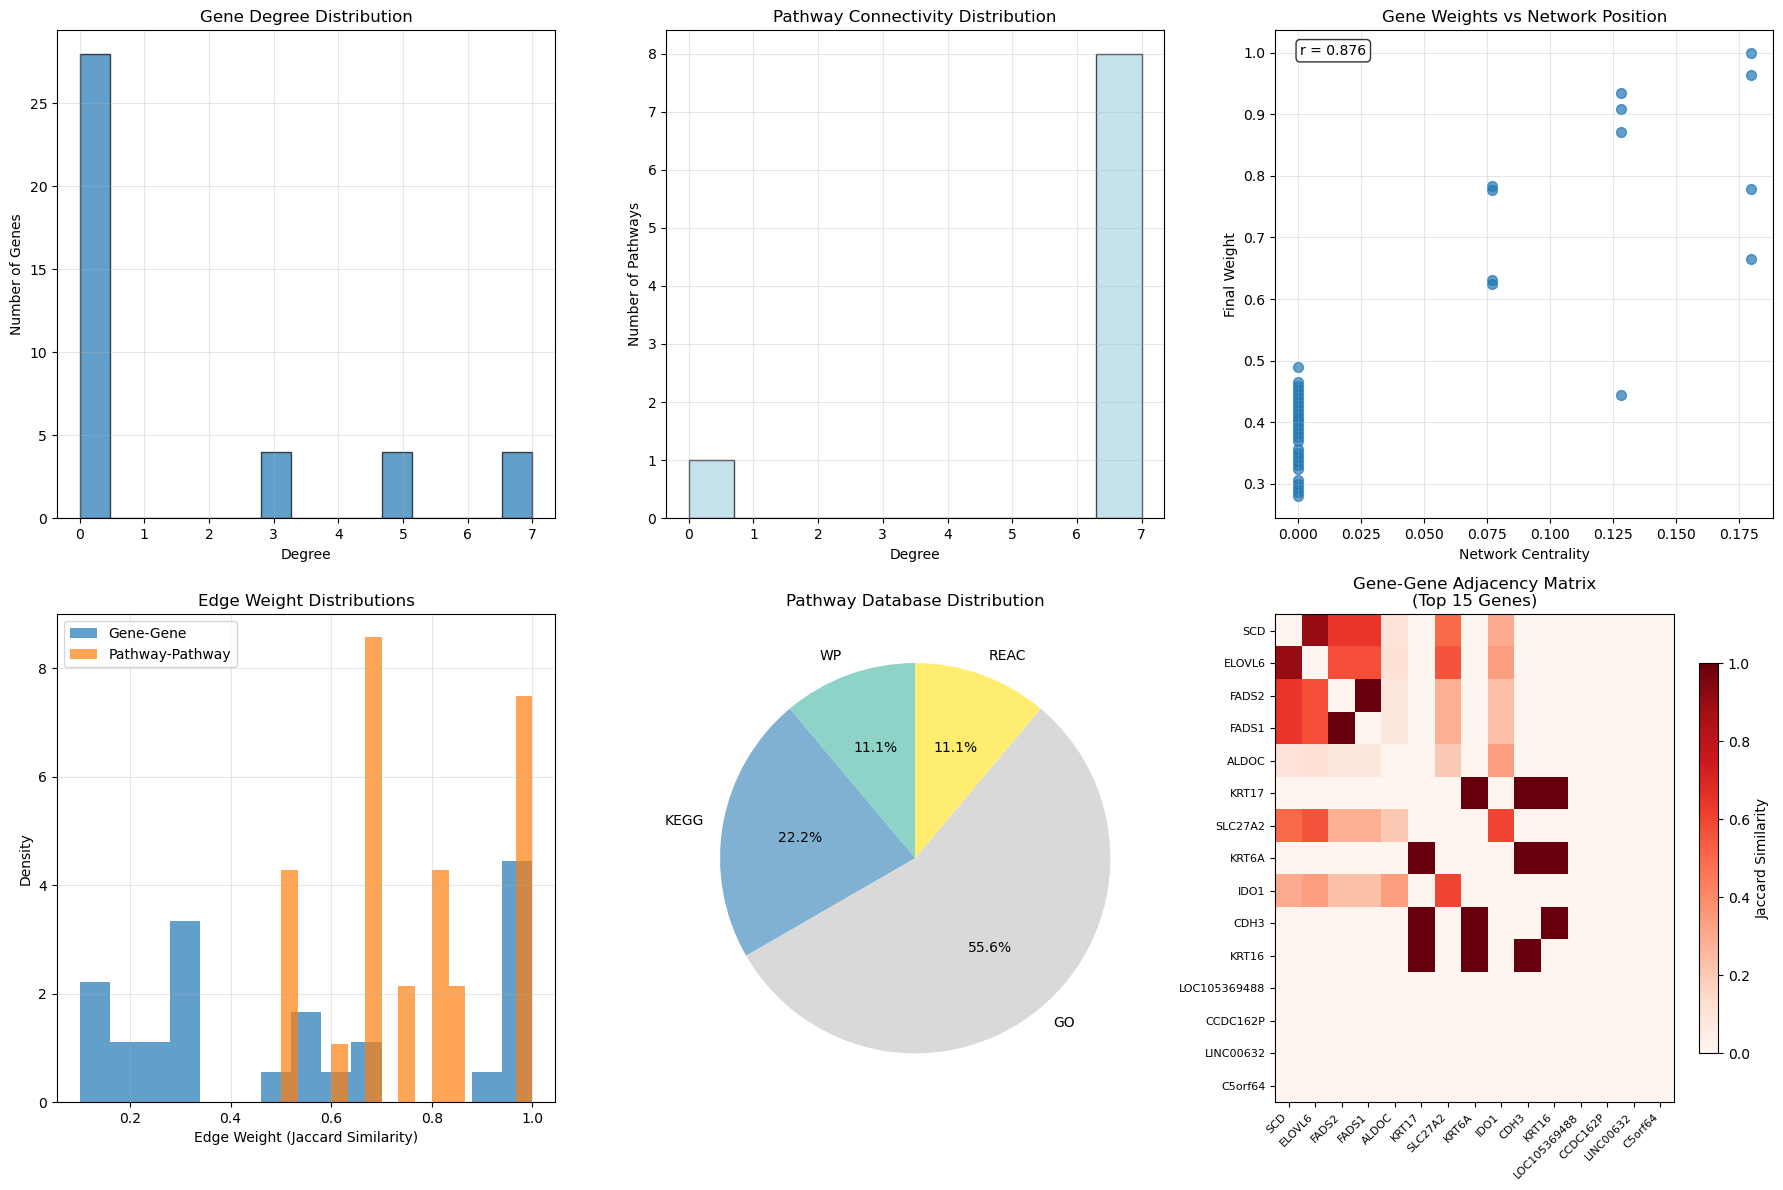


NETWORK ANALYSIS SUMMARY

1. GENE-GENE NETWORK:
   • 40 genes connected by pathway similarity
   • 30 connections (Jaccard > 0.1)
   • Network density: 0.038
   • Largest connected component: 8 genes

2. GENE-PATHWAY BIPARTITE NETWORK:
   • 25 top-weighted genes
   • 12 most connected pathways
   • 53 gene-pathway associations

3. PATHWAY SIMILARITY NETWORK:
   • 9 pathways with ≥4 genes
   • 28 pathway connections (Jaccard > 0.15)
   • Network density: 0.778

4. PATHWAY DATABASE COMPOSITION:
   • GO: 5 pathways (55.6%)
   • KEGG: 2 pathways (22.2%)
   • WP: 1 pathways (11.1%)
   • REAC: 1 pathways (11.1%)

5. TOP NETWORK HUBS:
   Gene hubs (most pathway connections):
     SCD: 7 connections (centrality=0.179)
     ELOVL6: 7 connections (centrality=0.179)
     SLC27A2: 7 connections (centrality=0.179)
     IDO1: 7 connections (centrality=0.179)
     FADS2: 5 connections (centrality=0.128)
   Pathway hubs (most gene overlaps):
     Omega 9 fatty acid s...: 7 connections (centrality=0.8

In [34]:
# -------- 4. Network Summary Dashboard --------
def create_network_summary():
    """
    Create a comprehensive summary of all network analyses
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # ---- Plot 1: Gene degree distribution ----
    ax = axes[0, 0]
    gene_degrees = [gene_network.degree(node) for node in gene_network.nodes()]
    ax.hist(gene_degrees, bins=15, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Degree')
    ax.set_ylabel('Number of Genes')
    ax.set_title('Gene Degree Distribution')
    ax.grid(True, alpha=0.3)
    
    # ---- Plot 2: Pathway connectivity distribution ----
    ax = axes[0, 1]
    pathway_degrees = [pathway_net.degree(node) for node in pathway_net.nodes()]
    ax.hist(pathway_degrees, bins=10, alpha=0.7, color='lightblue', edgecolor='black')
    ax.set_xlabel('Degree')
    ax.set_ylabel('Number of Pathways')
    ax.set_title('Pathway Connectivity Distribution')
    ax.grid(True, alpha=0.3)
    
    # ---- Plot 3: Gene weights vs network centrality ----
    ax = axes[0, 2]
    gene_centralities = [nx.degree_centrality(gene_network)[node] for node in gene_network.nodes()]
    gene_final_weights = [gene_weights.loc[node, 'final_weight'] for node in gene_network.nodes()]
    
    ax.scatter(gene_centralities, gene_final_weights, alpha=0.7, s=50)
    ax.set_xlabel('Network Centrality')
    ax.set_ylabel('Final Weight')
    ax.set_title('Gene Weights vs Network Position')
    ax.grid(True, alpha=0.3)
    
    # Add correlation
    correlation = np.corrcoef(gene_centralities, gene_final_weights)[0, 1]
    ax.text(0.05, 0.95, f'r = {correlation:.3f}', transform=ax.transAxes,
           bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # ---- Plot 4: Edge weight distributions ----
    ax = axes[1, 0]
    gene_edge_weights = [gene_network[u][v]['weight'] for u, v in gene_network.edges()]
    pathway_edge_weights = [pathway_net[u][v]['weight'] for u, v in pathway_net.edges()]
    
    ax.hist(gene_edge_weights, bins=15, alpha=0.7, label='Gene-Gene', density=True)
    ax.hist(pathway_edge_weights, bins=15, alpha=0.7, label='Pathway-Pathway', density=True)
    ax.set_xlabel('Edge Weight (Jaccard Similarity)')
    ax.set_ylabel('Density')
    ax.set_title('Edge Weight Distributions')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # ---- Plot 5: Source composition in pathway network ----
    ax = axes[1, 1]
    source_counts = {}
    for node in pathway_net.nodes():
        source = pathway_net.nodes[node]['source']
        source_counts[source] = source_counts.get(source, 0) + 1
    
    sources = list(source_counts.keys())
    counts = list(source_counts.values())
    colors = plt.cm.Set3(np.linspace(0, 1, len(sources)))
    
    wedges, texts, autotexts = ax.pie(counts, labels=sources, autopct='%1.1f%%', 
                                     colors=colors, startangle=90)
    ax.set_title('Pathway Database Distribution')
    
    # ---- Plot 6: Network connectivity matrix ----
    ax = axes[1, 2]
    
    # Create a simplified adjacency matrix for visualization
    top_genes_simple = gene_weights.nlargest(15, 'final_weight').index
    adj_simple = adj_matrix.loc[top_genes_simple, top_genes_simple]
    
    im = ax.imshow(adj_simple.values, cmap='Reds', aspect='auto')
    ax.set_xticks(range(len(top_genes_simple)))
    ax.set_yticks(range(len(top_genes_simple)))
    ax.set_xticklabels(top_genes_simple, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(top_genes_simple, fontsize=8)
    ax.set_title('Gene-Gene Adjacency Matrix\n(Top 15 Genes)')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Jaccard Similarity')
    
    plt.tight_layout()
    plt.savefig(OUTDIR / "network_summary_dashboard.png", dpi=300, bbox_inches='tight')
    plt.show()

# Create summary dashboard
print("Creating network summary dashboard...")
create_network_summary()

# ---- Overall Statistics Summary ----
print("\n" + "="*60)
print("NETWORK ANALYSIS SUMMARY")
print("="*60)

print(f"\n1. GENE-GENE NETWORK:")
print(f"   • {gene_network.number_of_nodes()} genes connected by pathway similarity")
print(f"   • {gene_network.number_of_edges()} connections (Jaccard > 0.1)")
print(f"   • Network density: {nx.density(gene_network):.3f}")
print(f"   • Largest connected component: {len(max(nx.connected_components(gene_network), key=len))} genes")

print(f"\n2. GENE-PATHWAY BIPARTITE NETWORK:")
print(f"   • {len(top_genes_bp)} top-weighted genes")
print(f"   • {len(top_pathways_bp)} most connected pathways")
print(f"   • {bipartite_net.number_of_edges()} gene-pathway associations")

print(f"\n3. PATHWAY SIMILARITY NETWORK:")
print(f"   • {pathway_net.number_of_nodes()} pathways with ≥4 genes")
print(f"   • {pathway_net.number_of_edges()} pathway connections (Jaccard > 0.15)")
print(f"   • Network density: {nx.density(pathway_net):.3f}")

# Source breakdown
source_counts = {}
for node in pathway_net.nodes():
    source = pathway_net.nodes[node]['source']
    source_counts[source] = source_counts.get(source, 0) + 1

print(f"\n4. PATHWAY DATABASE COMPOSITION:")
for source, count in sorted(source_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"   • {source}: {count} pathways ({count/sum(source_counts.values())*100:.1f}%)")

print(f"\n5. TOP NETWORK HUBS:")
print("   Gene hubs (most pathway connections):")
gene_hubs = sorted(nx.degree_centrality(gene_network).items(), key=lambda x: x[1], reverse=True)[:5]
for gene, centrality in gene_hubs:
    degree = gene_network.degree(gene)
    print(f"     {gene}: {degree} connections (centrality={centrality:.3f})")

print("   Pathway hubs (most gene overlaps):")
pathway_hubs = sorted(nx.degree_centrality(pathway_net).items(), key=lambda x: x[1], reverse=True)[:5]
for pathway, centrality in pathway_hubs:
    degree = pathway_net.degree(pathway)
    name = pathway_net.nodes[pathway]['display_name']
    print(f"     {name}: {degree} connections (centrality={centrality:.3f})")

print(f"\n6. FILES SAVED:")
saved_files = [
    "gene_network.png - Gene-gene similarity network",
    "gene_pathway_bipartite.png - Gene-pathway connections",
    "pathway_similarity_network.png - Pathway overlap network",
    "network_summary_dashboard.png - Statistical summary"
]
for file_desc in saved_files:
    print(f"   • {file_desc}")

print("\n" + "="*60)

In [35]:
# -------- Cumulative Explained Variance Analysis for Weighted PCA --------
print("=== Cumulative Explained Variance Analysis ===")

# Load necessary data first
df_gene_annot = pd.read_csv('../data/Human.GRCh38.p13.annot.tsv', sep='\t', index_col=None, header=0, low_memory=False)
gene_mapping = df_gene_annot[df_gene_annot['Symbol'].isin(weights.index)]
id_to_symbol = dict(zip(gene_mapping['GeneID'].astype(str), gene_mapping['Symbol']))
expr_vst = pd.read_csv("../results/GSE95640_DeSEQ2_normalized_counts.csv", index_col=0)
expr_vst = expr_vst[expr_vst.index.astype(str).isin(id_to_symbol.keys())]
expr_vst.index = expr_vst.index.astype(str).map(id_to_symbol)
expr_vst.index.name = None

# Perform weighted PCA with more components for comprehensive analysis
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Align expression matrix with weights
common_genes = list(set(expr_vst.index) & set(weights.index))
expr_aligned = expr_vst.loc[common_genes]
weights_aligned = weights.loc[common_genes, "final_weight"]

print(f"Using {len(common_genes)} genes for weighted PCA analysis")

# Standardize and weight
X = expr_aligned.T.values  # transpose: samples x genes
Xz = StandardScaler().fit_transform(X)
sqrtw = np.sqrt(weights_aligned.values)
Xw = Xz * sqrtw[None, :]

# Perform PCA with maximum possible components
max_components = min(len(common_genes)-1, X.shape[0]-1, 50)  # reasonable upper limit
pca_full = PCA(n_components=max_components, random_state=0)
Z_full = pca_full.fit_transform(Xw)

print(f"PCA with {max_components} components completed")

# Calculate cumulative explained variance
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Create detailed variance table
variance_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(explained_variance_ratio))],
    'Explained_Variance_%': explained_variance_ratio * 100,
    'Cumulative_Variance_%': cumulative_variance * 100
})

print(f"\nDetailed Explained Variance (first 20 components):")
print(variance_df.head(20).to_string(index=False, float_format='%.2f'))

# Key milestones
milestones = [50, 70, 80, 90, 95, 99]
print(f"\nKey Milestones:")
for milestone in milestones:
    components_needed = np.argmax(cumulative_variance >= milestone/100) + 1
    if cumulative_variance[components_needed-1] >= milestone/100:
        print(f"  {milestone}% variance explained by first {components_needed} components")
    else:
        print(f"  {milestone}% variance not reached with {max_components} components")

# Save full results
variance_df.to_csv(OUTDIR / "weighted_pca_explained_variance.csv", index=False)
print(f"\nFull variance table saved to: {OUTDIR / 'weighted_pca_explained_variance.csv'}")

=== Cumulative Explained Variance Analysis ===
Using 80 genes for weighted PCA analysis
PCA with 50 components completed

Detailed Explained Variance (first 20 components):
  PC  Explained_Variance_%  Cumulative_Variance_%
 PC1                 31.42                  31.42
 PC2                  8.86                  40.29
 PC3                  7.98                  48.27
 PC4                  4.46                  52.73
 PC5                  3.74                  56.47
 PC6                  3.32                  59.79
 PC7                  2.79                  62.58
 PC8                  2.54                  65.12
 PC9                  2.19                  67.31
PC10                  2.12                  69.44
PC11                  1.92                  71.36
PC12                  1.72                  73.08
PC13                  1.67                  74.74
PC14                  1.43                  76.18
PC15                  1.42                  77.60
PC16                  1.22 

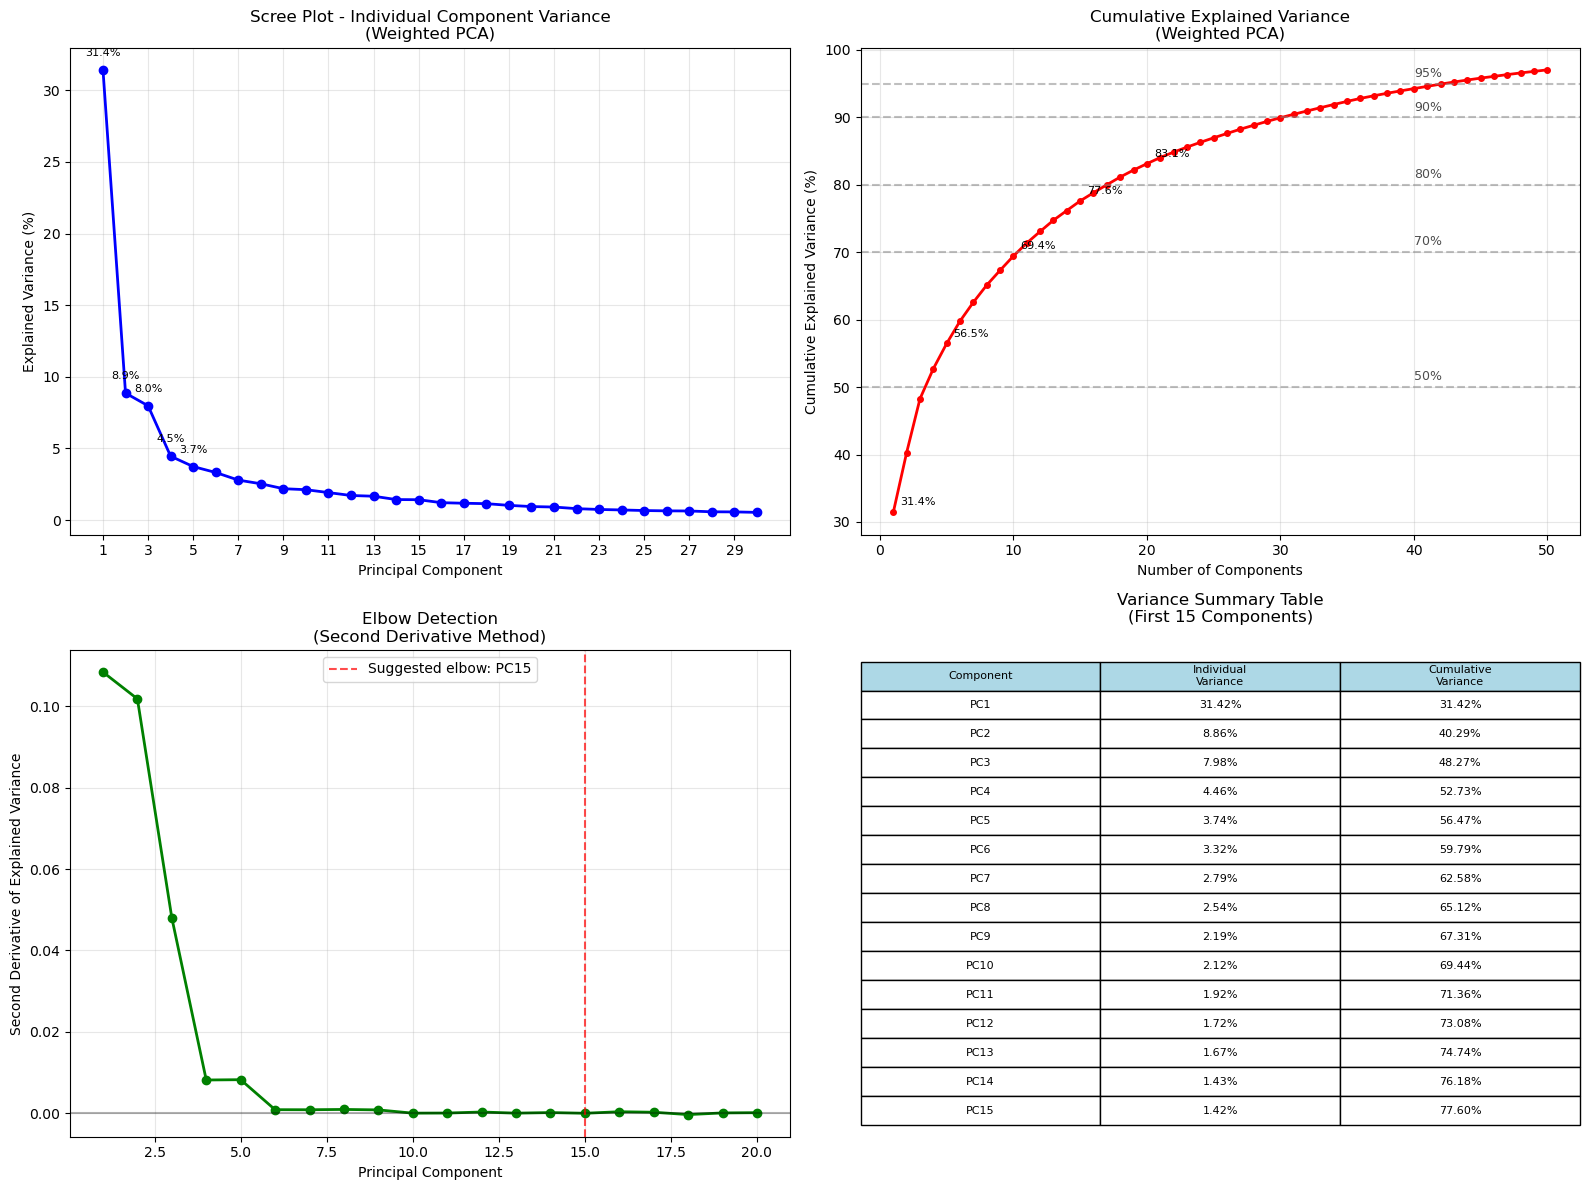

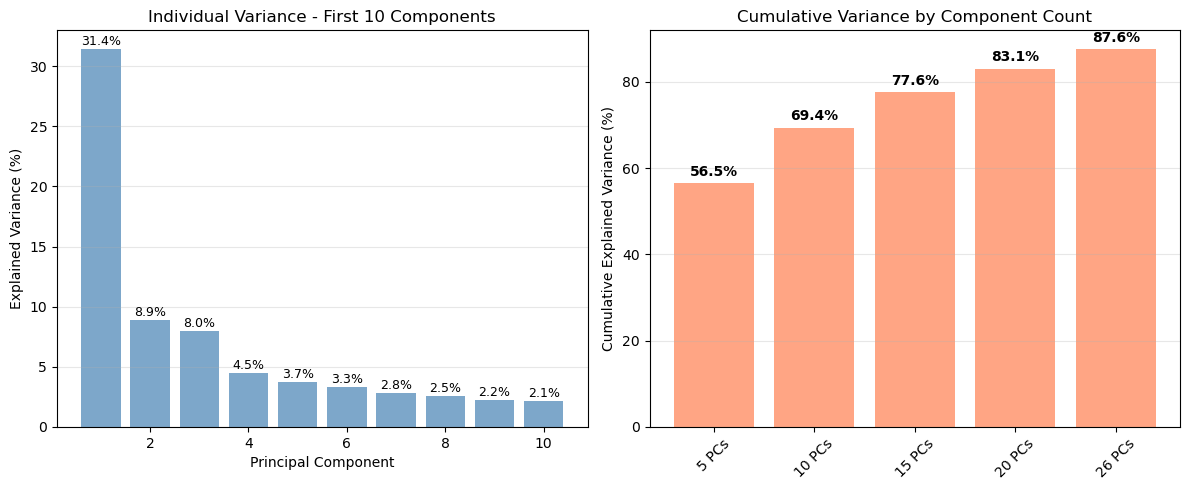


Visualization files saved:
  - weighted_pca_variance_analysis.png
  - weighted_pca_component_focus.png


In [36]:
# -------- Visualization of Cumulative Explained Variance --------
import matplotlib.pyplot as plt

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---- Plot 1: Scree plot (individual variance) ----
ax = axes[0, 0]
components_to_show = min(30, len(explained_variance_ratio))
ax.plot(range(1, components_to_show+1), explained_variance_ratio[:components_to_show] * 100, 'bo-', linewidth=2, markersize=6)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Scree Plot - Individual Component Variance\n(Weighted PCA)')
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, components_to_show+1, 2))

# Highlight first few components
for i in range(min(5, components_to_show)):
    ax.annotate(f'{explained_variance_ratio[i]*100:.1f}%', 
                (i+1, explained_variance_ratio[i]*100),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

# ---- Plot 2: Cumulative variance ----
ax = axes[0, 1]
ax.plot(range(1, len(cumulative_variance)+1), cumulative_variance * 100, 'ro-', linewidth=2, markersize=4)
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('Cumulative Explained Variance\n(Weighted PCA)')
ax.grid(True, alpha=0.3)

# Add milestone lines
for milestone in [50, 70, 80, 90, 95]:
    ax.axhline(y=milestone, color='gray', linestyle='--', alpha=0.5)
    ax.text(len(cumulative_variance)*0.8, milestone+1, f'{milestone}%', fontsize=9, alpha=0.7)

# Annotate key points
key_points = [1, 5, 10, 15, 20]
for point in key_points:
    if point <= len(cumulative_variance):
        ax.annotate(f'{cumulative_variance[point-1]*100:.1f}%', 
                    (point, cumulative_variance[point-1]*100),
                    textcoords="offset points", xytext=(5,5), ha='left', fontsize=8)

# ---- Plot 3: Elbow detection ----
ax = axes[1, 0]
# Calculate second derivative to find elbow
if len(explained_variance_ratio) >= 3:
    second_derivative = np.gradient(np.gradient(explained_variance_ratio))
    components_to_show_elbow = min(20, len(second_derivative))
    
    ax.plot(range(1, components_to_show_elbow+1), second_derivative[:components_to_show_elbow], 'go-', linewidth=2)
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Second Derivative of Explained Variance')
    ax.set_title('Elbow Detection\n(Second Derivative Method)')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Find potential elbow point (minimum of second derivative in first 15 components)
    elbow_candidates = second_derivative[:min(15, len(second_derivative))]
    elbow_point = np.argmin(elbow_candidates) + 1
    ax.axvline(x=elbow_point, color='red', linestyle='--', alpha=0.7, 
               label=f'Suggested elbow: PC{elbow_point}')
    ax.legend()

# ---- Plot 4: Comparison table view ----
ax = axes[1, 1]
ax.axis('tight')
ax.axis('off')

# Create a summary table for first 15 components
table_data = []
for i in range(min(15, len(explained_variance_ratio))):
    table_data.append([
        f'PC{i+1}',
        f'{explained_variance_ratio[i]*100:.2f}%',
        f'{cumulative_variance[i]*100:.2f}%'
    ])

table = ax.table(cellText=table_data,
                colLabels=['Component', 'Individual\nVariance', 'Cumulative\nVariance'],
                cellLoc='center',
                loc='center',
                colColours=['lightblue']*3)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)
ax.set_title('Variance Summary Table\n(First 15 Components)', pad=20)

plt.tight_layout()
plt.savefig(OUTDIR / "weighted_pca_variance_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

# ---- Create a focused plot for specific component ranges ----
plt.figure(figsize=(12, 5))

# Left plot: First 10 components
plt.subplot(1, 2, 1)
first_10 = min(10, len(explained_variance_ratio))
plt.bar(range(1, first_10+1), explained_variance_ratio[:first_10] * 100, alpha=0.7, color='steelblue')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Individual Variance - First 10 Components')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i in range(first_10):
    plt.text(i+1, explained_variance_ratio[i]*100 + 0.1, 
             f'{explained_variance_ratio[i]*100:.1f}%', 
             ha='center', va='bottom', fontsize=9)

# Right plot: Cumulative for different component counts
plt.subplot(1, 2, 2)
component_counts = [5, 10, 15, 20, 26]
cumulative_values = []
labels = []

for count in component_counts:
    if count <= len(cumulative_variance):
        cumulative_values.append(cumulative_variance[count-1] * 100)
        labels.append(f'{count} PCs')

plt.bar(labels, cumulative_values, alpha=0.7, color='coral')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Cumulative Variance by Component Count')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, value in enumerate(cumulative_values):
    plt.text(i, value + 1, f'{value:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTDIR / "weighted_pca_component_focus.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization files saved:")
print(f"  - weighted_pca_variance_analysis.png")
print(f"  - weighted_pca_component_focus.png")